In [1]:
import sys
sys.path.insert(1, '/home/fainx/MyPythonLibrary/MAR-RECAP/libmar/')
import climbasis as climb
from climbasis import *
import domain as dom
import myplot
import numpy.ma as ma
from myplot import *
import obsinfo as obs
from obsinfo import *
from datetime import datetime
import mar
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm
import cartopy.crs as ccrs
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import regionmask 
import matplotlib.ticker as ticker

# OROGRAPHY (MAR)

In [2]:
nx=ny=10

ds_pamir=xr.open_dataset('/home/amoryc/NST.2000.01.01.00.GRp.nc')#['SH']#[nx:-nx,ny:-ny]
SH_pamir=ds_pamir['SH'][nx:-nx,ny:-ny]
ICE_pamir=ds_pamir['ICE'][nx:-nx,ny:-ny]
LONS_pamir,LATS_pamir=ds_pamir.LON[nx:-nx,ny:-ny],ds_pamir.LAT[nx:-nx,ny:-ny]

In [3]:
LONS_pamir = LONS_pamir.rename({"y": "Y", "x": "X"})
LATS_pamir = LATS_pamir.rename({"y": "Y", "x": "X"})
SH_pamir = SH_pamir.rename({"y": "Y", "x": "X"})
ICE_pamir = ICE_pamir.rename({"y": "Y", "x": "X"})

LONS_pamir = LONS_pamir.assign_coords(X=np.round(LONS_pamir.X.values))
LONS_pamir = LONS_pamir.assign_coords(Y=np.round(LONS_pamir.Y.values))

LATS_pamir = LATS_pamir.assign_coords(X=np.round(LATS_pamir.X.values))
LATS_pamir = LATS_pamir.assign_coords(Y=np.round(LATS_pamir.Y.values))

SH_pamir = SH_pamir.assign_coords(X=np.round(SH_pamir.X.values))
SH_pamir = SH_pamir.assign_coords(Y=np.round(SH_pamir.Y.values))

ICE_pamir = ICE_pamir.assign_coords(X=np.round(ICE_pamir.X.values))
ICE_pamir = ICE_pamir.assign_coords(Y=np.round(ICE_pamir.Y.values))

# LOAD OBSERVATION DATA

### Functions

In [4]:
def mean_smb_remote_sensing_by_elevation(
    df,
    yr_start,
    yr_stop,
    elev_bins
):
    years = [str(y) for y in range(yr_start, yr_stop + 1)]

    data = df[["Zmed", "area"] + years].copy()

    # SMB moyen sur la période pour chaque glacier
    data["smb"] = data[years].mean(axis=1)

    # Supprimer les valeurs invalides
    data = data[
        np.isfinite(data["Zmed"]) &
        np.isfinite(data["smb"]) &
        (data["smb"] != 0)
    ]

    # Classes d'altitude
    data["elev_bin"] = pd.cut(
        data["Zmed"],
        bins=elev_bins
    )

    # Moyenne et écart-type par altitude
    result = (
        data
        .groupby("elev_bin", observed=True)["smb"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    # Centre de la classe
    result["altitude_m"] = result["elev_bin"].apply(lambda x: x.mid)

    return result

### Parameters

In [5]:
dz = 200

## HIMAP Areas

In [6]:
himap_folder = "/bettik/PROJECTS/pr-regional-climate/fainx/HMA_regions_Bolch/boundary_mountain_regions_hma_v3.shp"
regions = gpd.read_file(himap_folder)
regions = regions.to_crs(epsg=4326)
# regions[['OBJECTID','Primary_ID']]

In [7]:
regions_mask = regionmask.from_geopandas(
    regions,
    names="Primary_ID",   # ou autre colonne
    numbers="OBJECTID"
)

mask = regions_mask.mask(LONS_pamir, LATS_pamir)

region_id = dict(zip(regions["Primary_ID"], regions["OBJECTID"]))
#region_id

## WGMS Dataset

In [8]:
wgms_folder ='/bettik/PROJECTS/pr-regional-climate/fainx/PAMIR_SMB_OBS/WGMS-FoG-2026-02-10/'
wgms_file_glacier = 'glacier.csv'
wgms_file_smb = 'mass_balance.csv'

In [9]:
# WGMS Glacier ID
wgms_glaciers_list = [
    {"name": "Abramov", "id" : 732},
    {"name": "Zulmart", "id" : 13493},
    {"name": "Kyzylsu", "id" : 9276},
    # {"name": "Uruqmi", "id" : 853}, Hors domaine Pamir
    {"name": "Glacier_457", "id" : 21063}]

     
others_glaciers_list = [
    # {"name": "Grigoriev ", "lat":41.975, "lon" : 77.913}, Hors Pamir
    {"name": "Kangxiwa  ", "latitude": 38.28, "longitude" : 75.28},
    {"name": "Fedchenko", "latitude": 38.54063, "longitude" : 72.269816},
    {"name": "Kon Chukurbashi  ", "latitude": 39.250066, "longitude" :  73.557790}]

In [10]:
wgms_glacier_df = pd.read_csv(wgms_folder+wgms_file_glacier , sep=",")
wgms_glaciers_list_df = pd.DataFrame(wgms_glaciers_list)

wgms_glaciers = (
    wgms_glaciers_list_df
    .merge(wgms_glacier_df[["id", "latitude", "longitude"]], on="id", how="left")
)
wgms_glaciers['id']

0      732
1    13493
2     9276
3    21063
Name: id, dtype: int64

## RGI Database v6 (https://www.glims.org/RGI/randolph60.html)

In [11]:
rgi_v6 = gpd.read_file(
    "/bettik/PROJECTS/pr-regional-climate/fainx/PAMIR_SMB_OBS/RGI/v6/13_rgi60_CentralAsia.shp"
)
print(rgi_v6.columns)

Index(['RGIId', 'GLIMSId', 'BgnDate', 'EndDate', 'CenLon', 'CenLat',
       'O1Region', 'O2Region', 'Area', 'Zmin', 'Zmax', 'Zmed', 'Slope',
       'Aspect', 'Lmax', 'Status', 'Connect', 'Form', 'TermType', 'Surging',
       'Linkages', 'Name', 'geometry'],
      dtype='object')


## Dussaillant et al. (2025)

In [12]:
## this dataset reported on RGI v6
dus_folder ='/bettik/PROJECTS/pr-regional-climate/fainx/PAMIR_SMB_OBS/dussaillant_2025/'
dus_file_glacier = 'ASC_metadata.csv'
dus_file_smb = 'ASC_mwe.csv'

In [13]:
dus_glacier_df = pd.read_csv(dus_folder + dus_file_glacier)
dus_smb_df = pd.read_csv(dus_folder + dus_file_smb)
dus_df = dus_glacier_df.merge(dus_smb_df, on='outline_id', how='inner')

In [14]:
# Get glacier altitudes from RGI and include them to Dussaillant dataset

rgi_v6["key"] = rgi_v6["RGIId"]# .str[-5:]

dus_df["outline_id"] = dus_df["outline_id"].astype(str)
dus_df["key"] = dus_df["outline_id"]# .str[-5:]

dus_df = dus_df.merge(
    rgi_v6[["key", 'Zmin', 'Zmax', 'Zmed']], # checked that area, lon, and lat reported by Dussaillant are identical to RGI v6 database => OK
    on="key",
    how="left"
)

dus_df = dus_df.drop(columns=["key"])
dus_df = dus_df.rename(columns={"longitude": "lon"})
dus_df = dus_df.rename(columns={"latitude": "lat"})
dus_df = dus_df.rename(columns={"area_km2": "area"})

In [15]:
# Calculate mean SMB per decade

cols_2000_2009 = [str(y) for y in range(2000, 2010)]
cols_2010_2018 = [str(y) for y in range(2010, 2019)]

dus_df["2000_2009_mean"] = dus_df[cols_2000_2009].mean(axis=1)
dus_df["2010_2018_mean"] = dus_df[cols_2010_2018].mean(axis=1)

In [16]:
# Add Himap areas to Dussaillant dataset

gdf = gpd.GeoDataFrame(
    dus_df,
    geometry=gpd.points_from_xy(dus_df["lon"], dus_df["lat"]),
    crs="EPSG:4326"
)

gdf_joined = gpd.sjoin(
    gdf,
    regions[["OBJECTID", "Primary_ID", "geometry"]],
    how="left",
    predicate="within"
)

dus_df = gdf_joined.drop(columns="geometry")

In [17]:
# Extract Dussaillant sub dataset for areas of interest

dus_df_PA = dus_df[dus_df["OBJECTID"] == 5]
dus_df_WP = dus_df[dus_df["OBJECTID"] == 6]
dus_df_EP = dus_df[dus_df["OBJECTID"] == 7]

print('Nombre de glaciers recensé en Pamir Alay:', dus_df_PA.shape[0])
print('Nombre de glaciers recensé en Western Pamir:', dus_df_WP.shape[0])
print('Nombre de glaciers recensé en Eastern Pamir:', dus_df_EP.shape[0])

Nombre de glaciers recensé en Pamir Alay: 3151
Nombre de glaciers recensé en Western Pamir: 8833
Nombre de glaciers recensé en Eastern Pamir: 1400


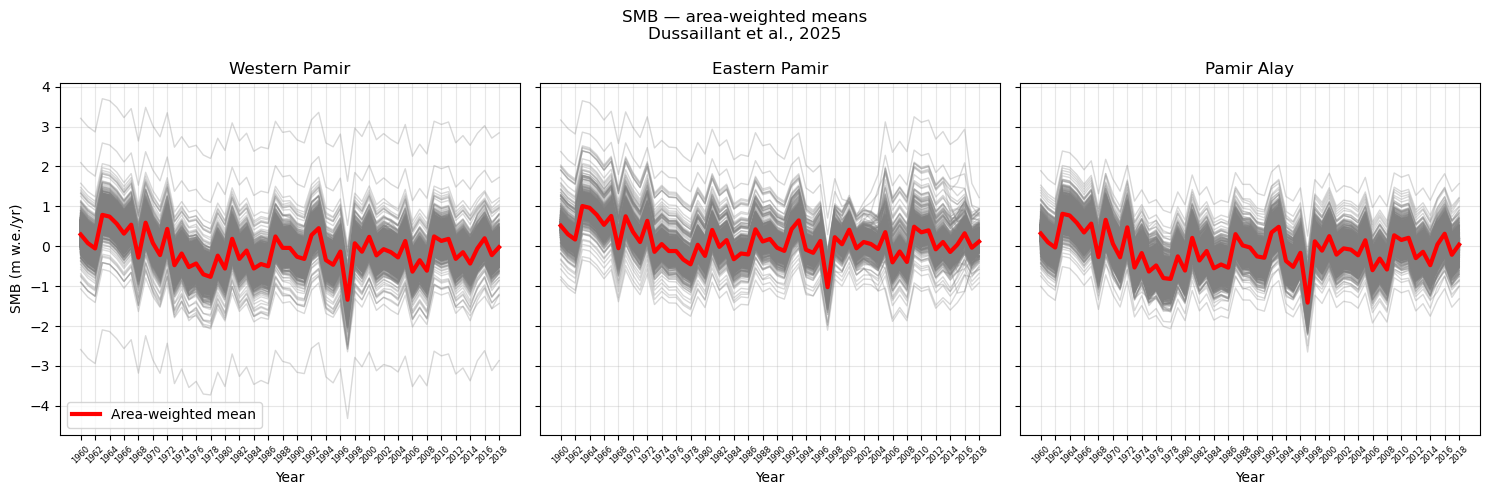

In [18]:
dfs = [dus_df_WP, dus_df_EP, dus_df_PA]
titles = ['Western Pamir', 'Eastern Pamir', 'Pamir Alay']

yrs = [str(y) for y in range(1960, 2019)]

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5),
    sharex=True,
    sharey=True
)

for ax, df, title in zip(axes, dfs, titles):

    # SMB cumulatif pour chaque glacier
    cum_smb = df[yrs]#.cumsum(axis=1)

    # -----------------------------------------
    # Moyenne pondérée par la surface du glacier
    # -----------------------------------------
    weighted_mean_cum = (
        cum_smb.mul(df["area"], axis=0).sum(axis=0)
        / df["area"].sum()
    )

    # Moyenne pondérée par la surface    
    ax.plot(yrs, cum_smb.T, color='gray', alpha=0.3, lw=1)
    
    ax.plot(
        yrs,
        weighted_mean_cum,
        color='red',
        lw=3,
        label='Area-weighted mean'
    )

    ax.set_title(title)
    ax.set_xlabel('Year')
    ax.tick_params(axis='x', labelsize=6)
    ax.grid(alpha=0.3)


axes[0].set_ylabel('SMB (m w.e./yr)')
axes[0].legend()

plt.suptitle(
    "SMB — area-weighted means\nDussaillant et al., 2025"
)

for ax in axes:
    ax.set_xticks(yrs[::2])
    ax.tick_params(axis='x', labelrotation=45)

plt.tight_layout()
plt.show()

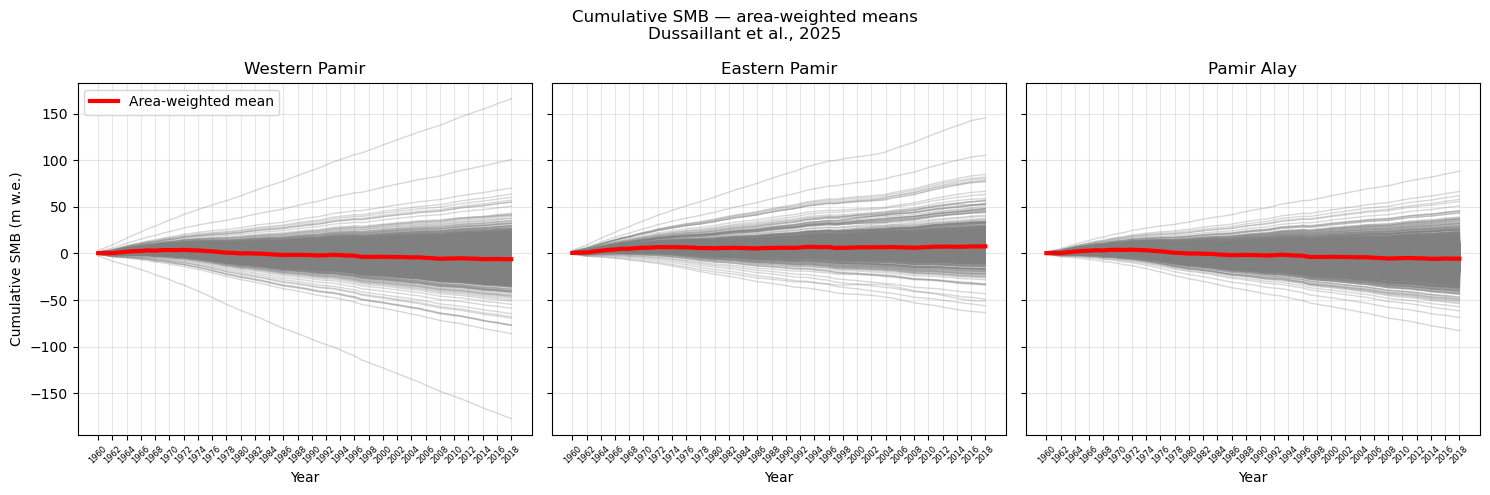

In [19]:
dfs = [dus_df_WP, dus_df_EP, dus_df_PA]
titles = ['Western Pamir', 'Eastern Pamir', 'Pamir Alay']

yrs = [str(y) for y in range(1960, 2019)]

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5),
    sharex=True,
    sharey=True
)

for ax, df, title in zip(axes, dfs, titles):

    # SMB cumulatif pour chaque glacier
    cum_smb = df[yrs].cumsum(axis=1)

    # -----------------------------------------
    # Moyenne pondérée par la surface du glacier
    # -----------------------------------------
    weighted_mean_cum = (
        cum_smb.mul(df["area"], axis=0).sum(axis=0)
        / df["area"].sum()
    )

    # Moyenne pondérée par la surface    
    ax.plot(yrs, cum_smb.T, color='gray', alpha=0.3, lw=1)
    
    ax.plot(
        yrs,
        weighted_mean_cum,
        color='red',
        lw=3,
        label='Area-weighted mean'
    )

    ax.set_title(title)
    ax.set_xlabel('Year')
    ax.tick_params(axis='x', labelsize=6)
    ax.grid(alpha=0.3)


axes[0].set_ylabel('Cumulative SMB (m w.e.)')
axes[0].legend()

plt.suptitle(
    "Cumulative SMB — area-weighted means\nDussaillant et al., 2025"
)

for ax in axes:
    ax.set_xticks(yrs[::2])
    ax.tick_params(axis='x', labelrotation=45)

plt.tight_layout()
plt.show()

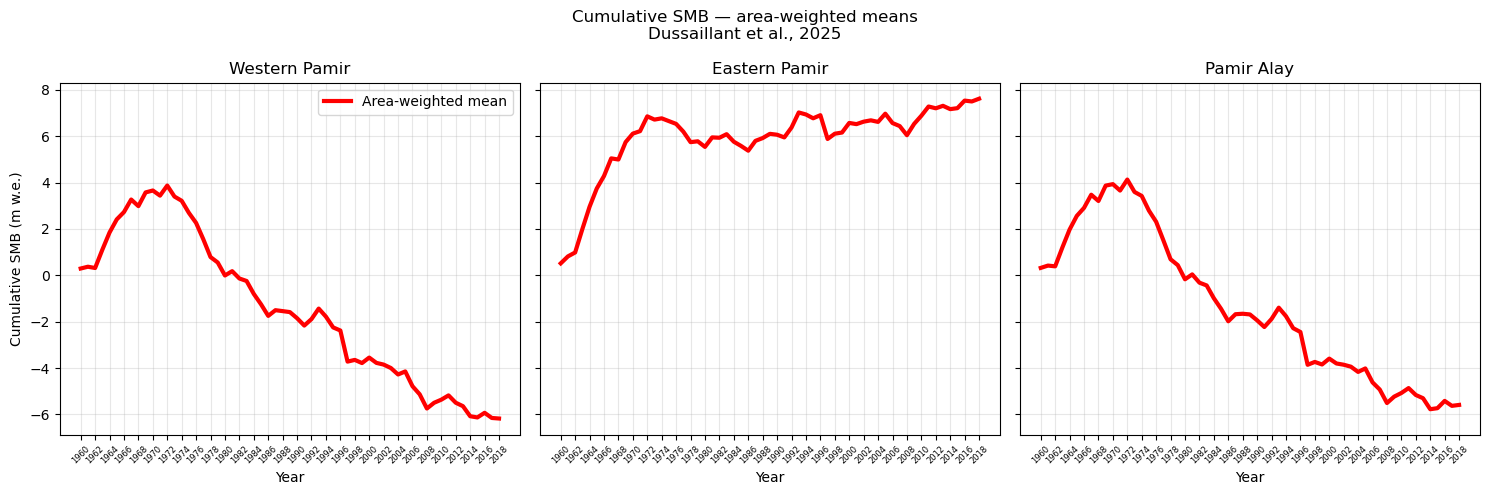

In [20]:
dfs = [dus_df_WP, dus_df_EP, dus_df_PA]
titles = ['Western Pamir', 'Eastern Pamir', 'Pamir Alay']

yrs = [str(y) for y in range(1960, 2019)]

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5),
    sharex=True,
    sharey=True
)

for ax, df, title in zip(axes, dfs, titles):

    # SMB cumulatif pour chaque glacier
    cum_smb = df[yrs].cumsum(axis=1)

    # -----------------------------------------
    # Moyenne pondérée par la surface du glacier
    # -----------------------------------------
    weighted_mean_cum = (
        cum_smb.mul(df["area"], axis=0).sum(axis=0)
        / df["area"].sum()
    )

    # Moyenne pondérée par la surface    
    
    ax.plot(
        yrs,
        weighted_mean_cum,
        color='red',
        lw=3,
        label='Area-weighted mean'
    )

    ax.set_title(title)
    ax.set_xlabel('Year')
    ax.tick_params(axis='x', labelsize=6)
    ax.grid(alpha=0.3)


axes[0].set_ylabel('Cumulative SMB (m w.e.)')
axes[0].legend()

plt.suptitle(
    "Cumulative SMB — area-weighted means\nDussaillant et al., 2025"
)

for ax in axes:
    ax.set_xticks(yrs[::2])
    ax.tick_params(axis='x', labelrotation=45)

plt.tight_layout()
plt.show()

In [21]:
yr_start = 2000
yr_stop = 2018

elev_bins = np.arange(2000, 7000 + dz, dz)

PA_dus_elevation = mean_smb_remote_sensing_by_elevation(
    dus_df_PA, yr_start, yr_stop, elev_bins
)

EP_dus_elevation = mean_smb_remote_sensing_by_elevation(
    dus_df_EP, yr_start, yr_stop, elev_bins
)

WP_dus_elevation = mean_smb_remote_sensing_by_elevation(
    dus_df_WP, yr_start, yr_stop, elev_bins
)

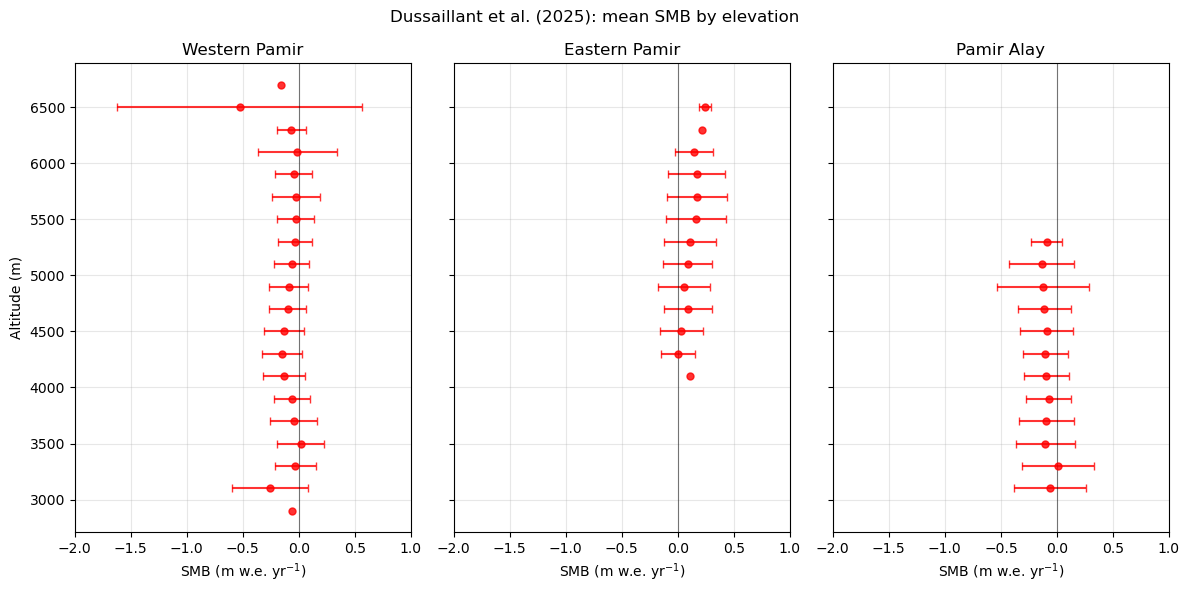

In [22]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 6),
    sharey=True
)

results = [
    WP_dus_elevation,
    EP_dus_elevation,
    PA_dus_elevation
]

titles = [
    "Western Pamir",
    "Eastern Pamir",    
    "Pamir Alay"
]

for ax, result, title in zip(axes, results, titles):
    ax.errorbar(
        result["mean"],
        result["altitude_m"],
        xerr=result["std"],
        fmt="o",
        markersize=5,
        capsize=3,
        alpha=0.8,
        color="red")

    ax.axvline(
        0,
        color="black",
        linewidth=0.8,
        alpha=0.5)

    ax.set_xlim(-2, 1)
    ax.set_title(title)
    ax.set_xlabel("SMB (m w.e. yr$^{-1}$)")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Altitude (m)")

plt.suptitle("Dussaillant et al. (2025): mean SMB by elevation")

plt.tight_layout()
plt.show()

## Hugonnet et al. (2021)

In [23]:
hug_df_all = pd.read_csv('/bettik/PROJECTS/pr-regional-climate/bricej/dh_HIMAP_rates.csv')

subregs = ['Western Pamir', 'Pamir Alay', 'Eastern Pamir']
periods = ['2000-01-01_2010-01-01', '2010-01-01_2020-01-01', '2000-01-01_2020-01-01']
hug_df = hug_df_all[
    hug_df_all['subreg'].isin(subregs) &
    hug_df_all['period'].isin(periods)
]
hug_df = hug_df[['subreg', 'period', 'dhdt']]
hug_df = hug_df.rename(columns={"subreg": "region"})

## Barandun et al. (2021)

In [24]:
# https://zenodo.org/records/4782116?preview_file=Barandunetal_annualtimeseries_mb.csv
# this dataset reported on RGI v6
baran_df = pd.read_csv('/bettik/PROJECTS/pr-regional-climate/fainx/PAMIR_SMB_OBS/Barandunetal_annualtimeseries_mb.csv', sep=",")

In [25]:
# Get glacier altitudes  and lat/lon from RGI and include them to Baraudum dataset

rgi_v6["key"] = rgi_v6["RGIId"].str[-5:]

baran_df["RGI_code"] = baran_df["RGI_code"].astype(str)
baran_df["key"] = baran_df["RGI_code"].str[-5:]

baran_df = baran_df.merge(
    rgi_v6[["key", 'Zmin', 'Zmax', 'Zmed','Area','CenLon', 'CenLat']], # checked that area, lon, and lat reported by Dussaillant are identical to RGI v6 database => OK
    on="key",
    how="left"
)

baran_df = baran_df.drop(columns=["key"])
baran_df = baran_df.rename(columns={"CenLon": "lon"})
baran_df = baran_df.rename(columns={"CenLat": "lat"})
baran_df = baran_df.rename(columns={"Area": "area"})

In [26]:
# Calculate mean SMB per decade

cols_2000_2009 = [str(y) for y in range(2000, 2010)]
cols_2010_2018 = [str(y) for y in range(2010, 2019)]
cols_2000_2018 = [str(y) for y in range(2000, 2019)]

baran_df["2000_2009_mean"] = baran_df[cols_2000_2009].mean(axis=1)
baran_df["2010_2018_mean"] = baran_df[cols_2010_2018].mean(axis=1)
baran_df["2000_2018_mean"] = baran_df[cols_2000_2018].mean(axis=1)

In [27]:
# Add Himap areas to Dussaillant dataset

gdf = gpd.GeoDataFrame(
    baran_df,
    geometry=gpd.points_from_xy(baran_df["lon"], baran_df["lat"]),
    crs="EPSG:4326"
)

gdf_joined = gpd.sjoin(
    gdf,
    regions[["OBJECTID", "Primary_ID", "geometry"]],
    how="left",
    predicate="within"
)

baran_df = gdf_joined.drop(columns="geometry")

In [28]:
# # Extract  sub-dataset for areas of interest

baran_df_PA = baran_df[baran_df["OBJECTID"] == 5]
baran_df_WP = baran_df[baran_df["OBJECTID"] == 6]
baran_df_EP = baran_df[baran_df["OBJECTID"] == 7]

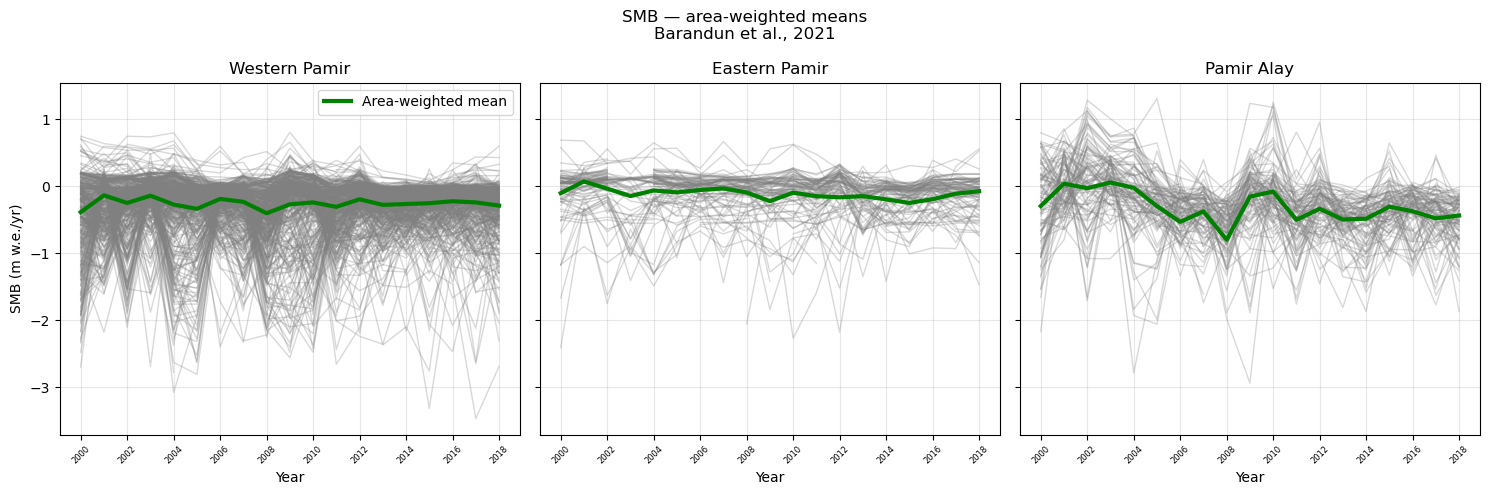

In [29]:
dfs = [baran_df_WP, baran_df_EP, baran_df_PA]
titles = ['Western Pamir', 'Eastern Pamir', 'Pamir Alay']

yrs = [str(y) for y in range(2000, 2019)]

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5),
    sharex=True,
    sharey=True
)

for ax, df, title in zip(axes, dfs, titles):

    # SMB cumulatif pour chaque glacier
    cum_smb = df[yrs]#.cumsum(axis=1)

    # Moyenne pondérée par la surface du glacier
    weighted_mean_cum = (
        cum_smb.mul(df["area"], axis=0).sum(axis=0)
        / df["area"].sum()
    )

    # Moyenne pondérée par la surface    
    ax.plot(yrs, cum_smb.T, color='gray', alpha=0.3, lw=1)
    
    ax.plot(
        yrs,
        weighted_mean_cum,
        color='green',
        lw=3,
        label='Area-weighted mean'
    )

    ax.set_title(title)
    ax.set_xlabel('Year')
    ax.tick_params(axis='x', labelsize=6)
    ax.grid(alpha=0.3)


axes[0].set_ylabel('SMB (m w.e./yr)')
axes[0].legend()

plt.suptitle(
    "SMB — area-weighted means\nBarandun et al., 2021"
)

for ax in axes:
    ax.set_xticks(yrs[::2])
    ax.tick_params(axis='x', labelrotation=45)

plt.tight_layout()
plt.show()

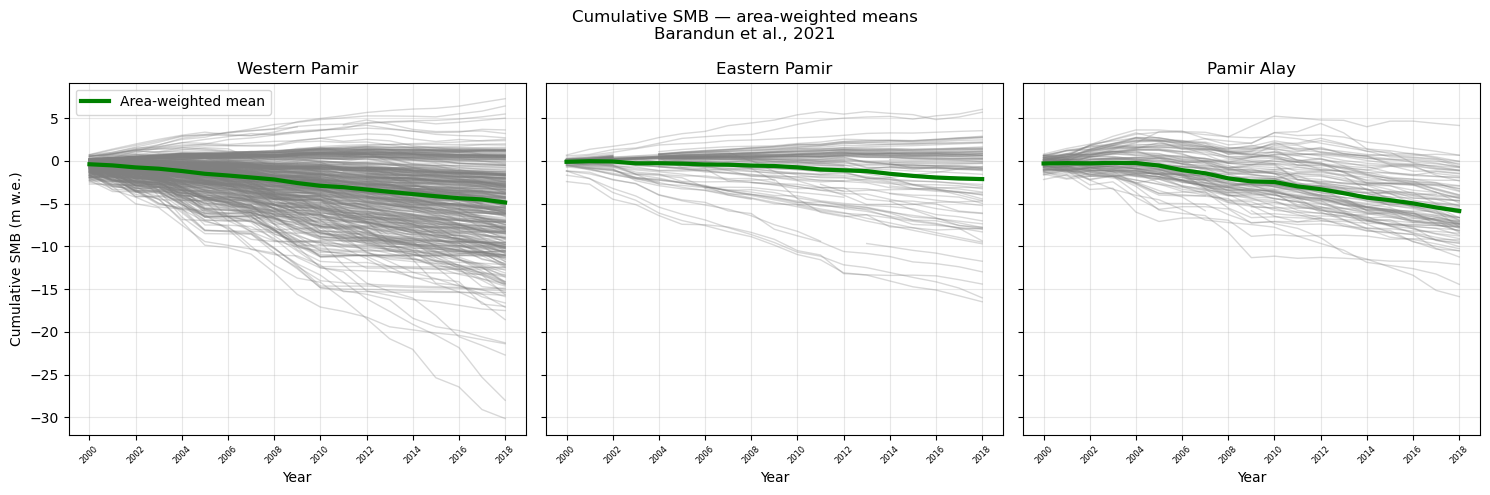

In [30]:
dfs = [baran_df_WP, baran_df_EP, baran_df_PA]
titles = ['Western Pamir', 'Eastern Pamir', 'Pamir Alay']

yrs = [str(y) for y in range(2000, 2019)]

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5),
    sharex=True,
    sharey=True
)

for ax, df, title in zip(axes, dfs, titles):

    # SMB cumulatif pour chaque glacier
    cum_smb = df[yrs].cumsum(axis=1)

    # Moyenne pondérée par la surface du glacier
    weighted_mean_cum = (
        cum_smb.mul(df["area"], axis=0).sum(axis=0)
        / df["area"].sum()
    )

    # Moyenne pondérée par la surface    
    ax.plot(yrs, cum_smb.T, color='gray', alpha=0.3, lw=1)
    
    ax.plot(
        yrs,
        weighted_mean_cum,
        color='green',
        lw=3,
        label='Area-weighted mean'
    )

    ax.set_title(title)
    ax.set_xlabel('Year')
    ax.tick_params(axis='x', labelsize=6)
    ax.grid(alpha=0.3)


axes[0].set_ylabel('Cumulative SMB (m w.e.)')
axes[0].legend()

plt.suptitle(
    "Cumulative SMB — area-weighted means\nBarandun et al., 2021"
)

for ax in axes:
    ax.set_xticks(yrs[::2])
    ax.tick_params(axis='x', labelrotation=45)

plt.tight_layout()
plt.show()

In [31]:
yr_start = 2000
yr_stop = 2018

elev_bins = np.arange(2000, 7000 + dz, dz)

PA_baran_elevation = mean_smb_remote_sensing_by_elevation(
    baran_df_PA, yr_start, yr_stop, elev_bins
)

EP_baran_elevation = mean_smb_remote_sensing_by_elevation(
    baran_df_EP, yr_start, yr_stop, elev_bins
)

WP_baran_elevation = mean_smb_remote_sensing_by_elevation(
    baran_df_WP, yr_start, yr_stop, elev_bins
)

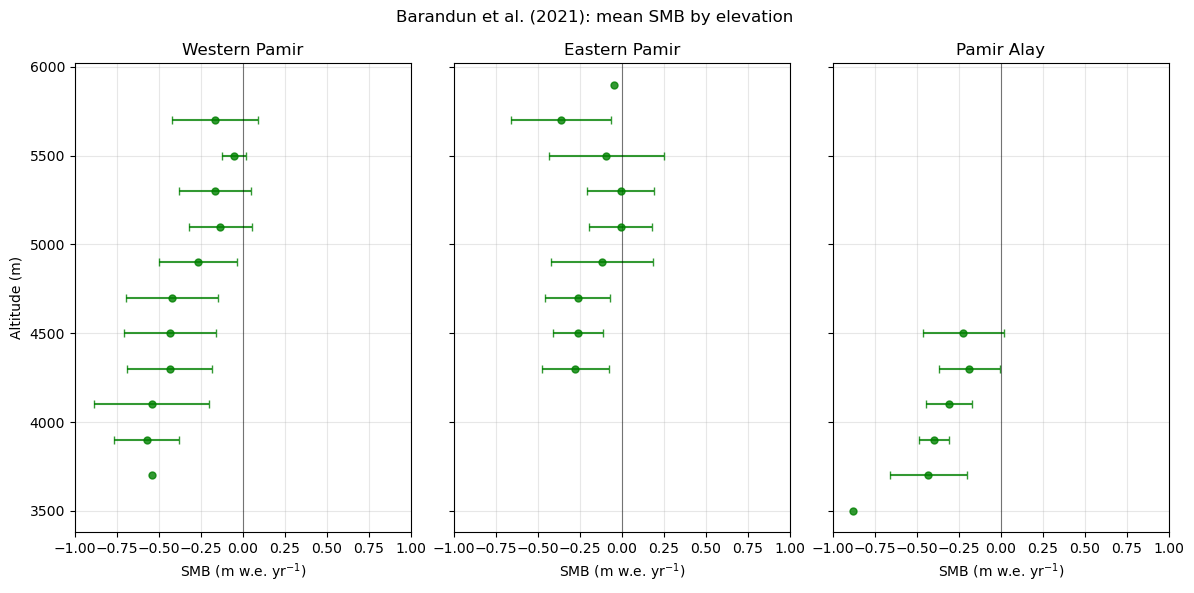

In [32]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 6),
    sharey=True
)

results = [
    WP_baran_elevation,
    EP_baran_elevation,
    PA_baran_elevation
]

titles = [
    "Western Pamir",
    "Eastern Pamir",    
    "Pamir Alay"
]


for ax, result, title in zip(axes, results, titles):

    ax.errorbar(
        result["mean"],
        result["altitude_m"],
        xerr=result["std"],
        fmt="o",
        markersize=5,
        capsize=3,
        alpha=0.8,
        color='green'
    )

    ax.axvline(
        0,
        color="black",
        linewidth=0.8,
        alpha=0.5
    )

    ax.set_xlim(-1, 1)
    ax.set_title(title)
    ax.set_xlabel("SMB (m w.e. yr$^{-1}$)")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Altitude (m)")

plt.suptitle(
    "Barandun et al. (2021): mean SMB by elevation"
)

plt.tight_layout()
plt.show()

# COMPARE OBSERVATION DATASET

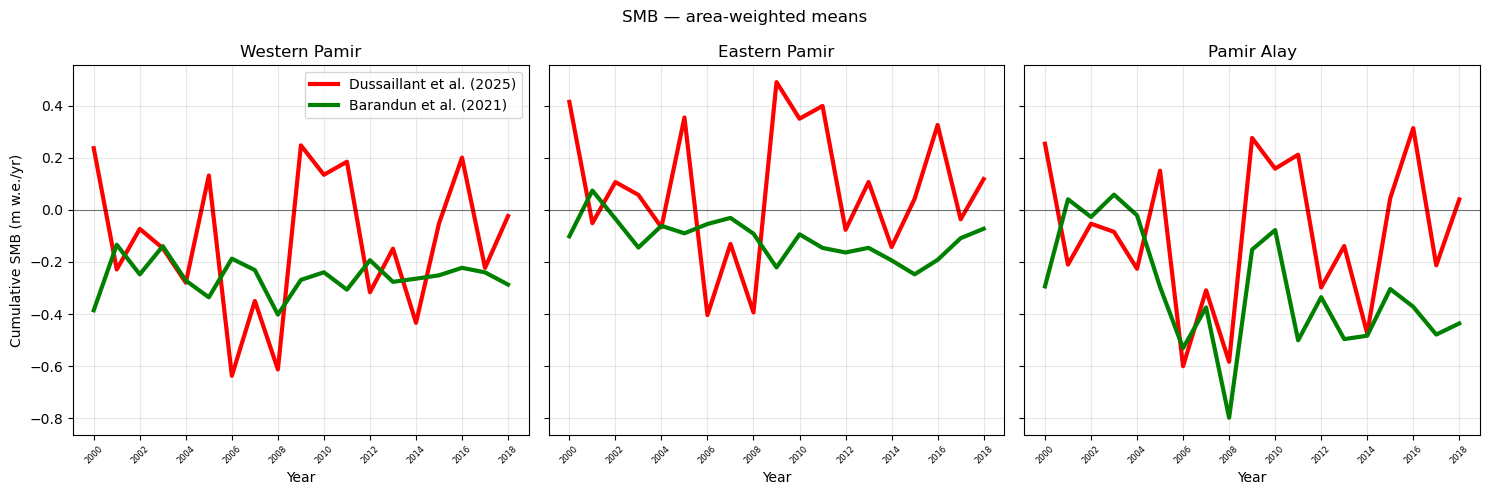

In [73]:
df_dus   = [dus_df_WP, dus_df_EP, dus_df_PA]
df_baran = [baran_df_WP, baran_df_EP, baran_df_PA]
titles   = ['Western Pamir', 'Eastern Pamir', 'Pamir Alay']

yrs = [str(y) for y in range(2000, 2019)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

for ax, title, df_d, df_b in zip(axes, titles, df_dus, df_baran):

    for df, color, label in [
        (df_d, 'red',  'Dussaillant et al. (2025)'),
        (df_b, 'green', 'Barandun et al. (2021)'),
    ]:
        # SMB cumulatif pour chaque glacier
        cum_smb = df[yrs]#.cumsum(axis=1)

        # Moyenne pondérée par la surface du glacier
        weighted_mean_cum = (
            cum_smb.mul(df["area"], axis=0).sum(axis=0)
            / df["area"].sum()
        )

        ax.plot(yrs, weighted_mean_cum, color=color, lw=3, label=label) 
    
    ax.set_title(title)
    ax.set_xlabel('Year')
    ax.tick_params(axis='x', labelsize=6)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Cumulative SMB (m w.e./yr)')
axes[0].legend()
plt.suptitle("SMB — area-weighted means")

for ax in axes:
    ax.set_xticks(yrs[::2])
    ax.tick_params(axis='x', labelrotation=45)

    ax.axhline(
        0,
        color="black",
        lw=0.8,
        alpha=0.5
    )

plt.tight_layout()
plt.show()

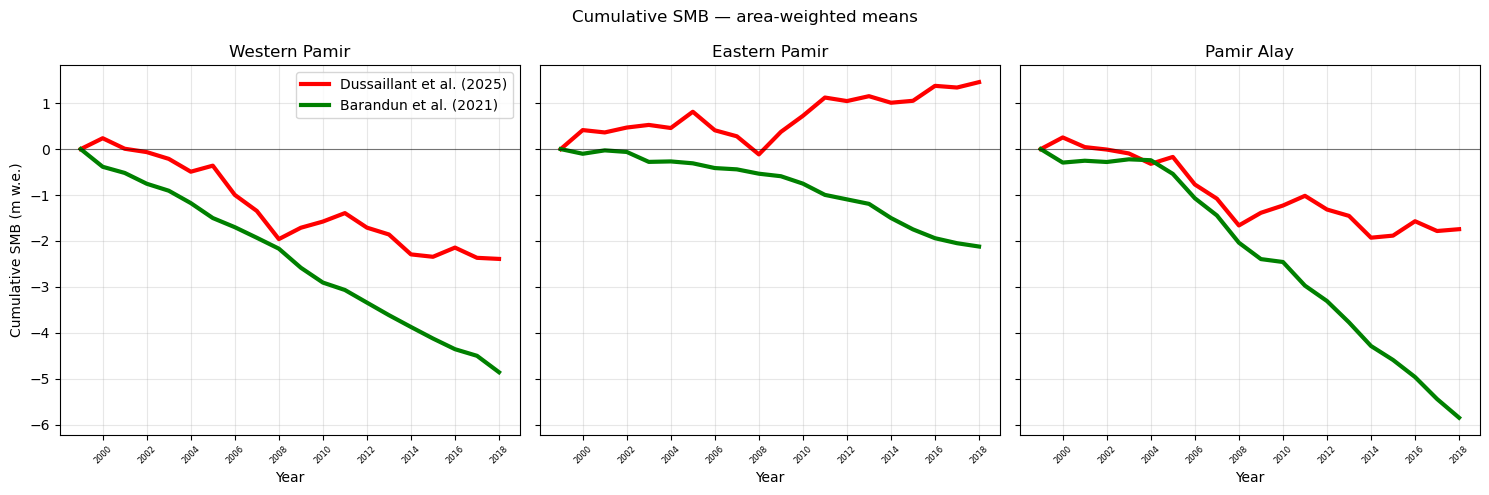

In [74]:
df_dus   = [dus_df_WP, dus_df_EP, dus_df_PA]
df_baran = [baran_df_WP, baran_df_EP, baran_df_PA]
titles   = ['Western Pamir', 'Eastern Pamir', 'Pamir Alay']

yrs = [str(y) for y in range(2000, 2019)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

for ax, title, df_d, df_b in zip(axes, titles, df_dus, df_baran):

    for df, color, label in [
        (df_d, 'red',  'Dussaillant et al. (2025)'),
        (df_b, 'green', 'Barandun et al. (2021)'),
    ]:
        # SMB cumulatif pour chaque glacier
        cum_smb = df[yrs].cumsum(axis=1)

        # Moyenne pondérée par la surface du glacier
        weighted_mean_cum = (
            cum_smb.mul(df["area"], axis=0).sum(axis=0)
            / df["area"].sum()
        )

        # Partir d'un cumul nul 
        yrs_plot = [str(int(yrs[0]) - 1)] + yrs
        
        weighted_mean_cum_plot = np.insert(
            weighted_mean_cum.values,
            0,
            0
        )
        
        ax.plot(yrs_plot, weighted_mean_cum_plot, color=color, lw=3, label=label)
#        ax.plot(yrs, weighted_mean_cum, color=color, lw=3, label=label) # pour vérif
    
    ax.set_title(title)
    ax.set_xlabel('Year')
    ax.tick_params(axis='x', labelsize=6)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Cumulative SMB (m w.e.)')
axes[0].legend()
plt.suptitle("Cumulative SMB — area-weighted means")

for ax in axes:
    ax.set_xticks(yrs[::2])
    ax.tick_params(axis='x', labelrotation=45)

    ax.axhline(
        0,
        color="black",
        lw=0.8,
        alpha=0.5
    )


plt.tight_layout()
plt.show()

# LOAD MAR DATA

In [35]:
domain = 'GRp'

In [36]:
sourceData_1='/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/' + domain +'/spin2/work/monthly/'
sourceData_2='/bettik/PROJECTS/pr-regional-climate/fainx/'
sourceData_3='/bettik/PROJECTS/pr-regional-climate/santolam/HARv2/'
folder_figure = '/bettik/PROJECTS/pr-regional-climate/fainx/figures/' + domain +'/'

/tmp/ipykernel_387389/2196253707.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


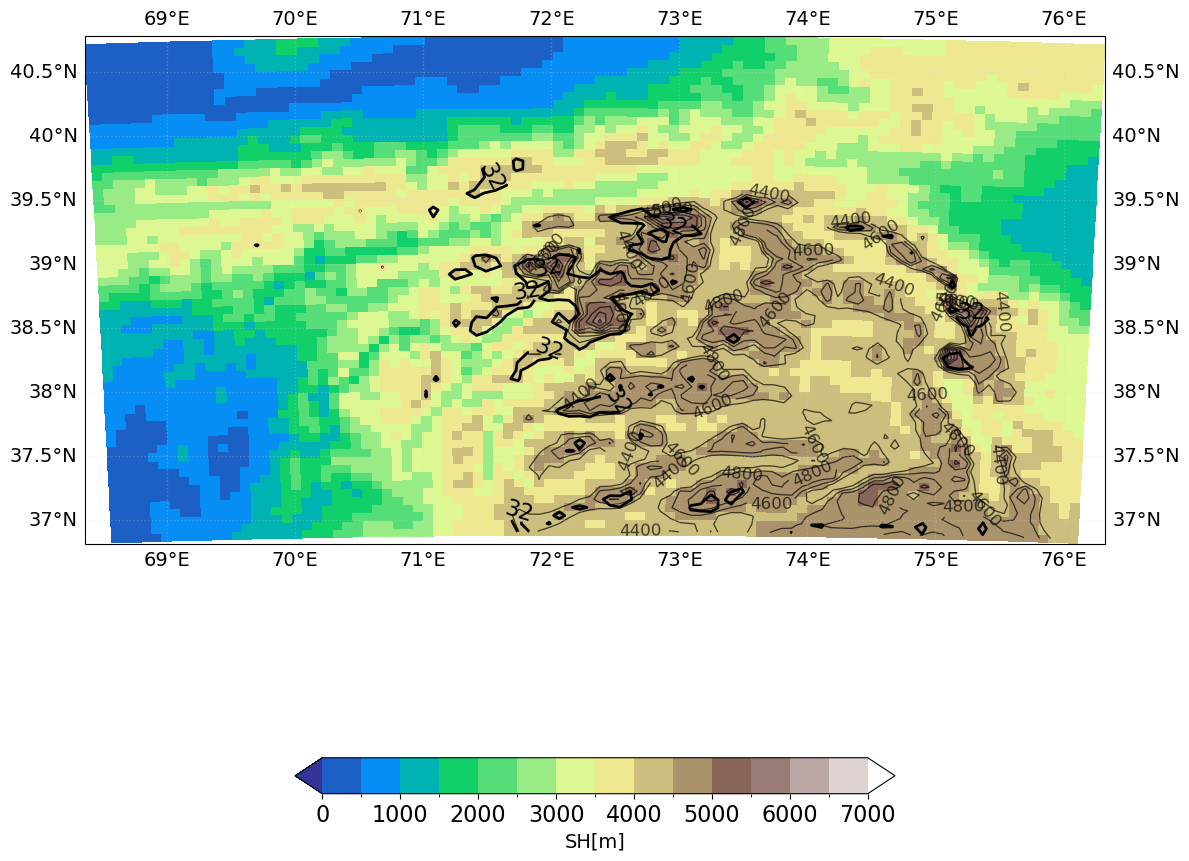

In [37]:
ice_level=32# % of ice on grid cell

clevs=np.arange(0,7500,500)
cmap_mod = plt.get_cmap('terrain')
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap_mod.N, extend="both")

fig, ax = plt.subplots(figsize=(12, 12),
                         subplot_kw={'projection': ccrs.PlateCarree()})


im = ax.pcolormesh(LONS_pamir, LATS_pamir, SH_pamir,
                       transform=ccrs.PlateCarree(), cmap=cmap_mod,norm=norm,shading='auto')

ax.set_aspect(1.0)
SH1 = ax.contour(LONS_pamir, LATS_pamir, SH_pamir,
                             levels=[4400,4600,4800,5000,5200,5400,5600,5800,6000,6200,6400,6600,6800,7000],
                             colors="k", linewidths=0.9, alpha=0.7,
                             transform=ccrs.PlateCarree())
ax.clabel(SH1, inline=True, fontsize=12, fmt="%d")
    
ICE2= ax.contour(LONS_pamir, LATS_pamir, ICE_pamir,
                    levels=[ice_level],
                    colors="black", linewidths=2.0, alpha=1.0,
                    transform=ccrs.PlateCarree())

ax.clabel(ICE2, inline=True, fontsize=16, fmt="%d")
 
# ax.set_extent([71, 72, 39.4, 40], crs=ccrs.PlateCarree())

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color="lightgray", alpha=0.3, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}

  
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar.set_label(f"{'SH'}[{'m'}]", fontsize=14)
cbar.ax.tick_params(labelsize=16)

fig.subplots_adjust(left=0.2, right=0.8, top=0.95, bottom=0.1, wspace=0.05, hspace=0.2)
plt.tight_layout()

plt.show()

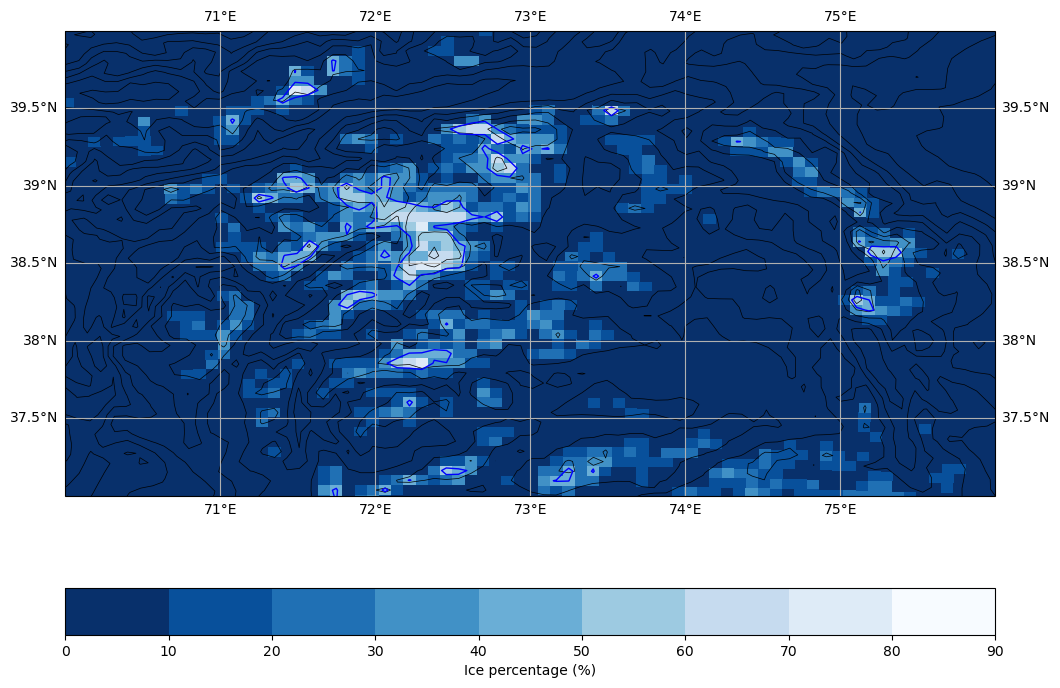

In [38]:
ice_level = 40 # Seuil à partir duquel on considère qu'on observe de la glace

clevs = np.arange(0, 100, 10) # Echelle de couleur de 0 à 100% tous les 10%
cmap = plt.get_cmap("Blues_r") # Palette de couleur bleu (reverse) pour voir le % de glace par grille
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N) 


fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré

#### Courbes de niveau (tous les 500m) ####
SH = ax.contour(LONS_pamir, LATS_pamir, SH_pamir, 
           levels=[500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000], # Affichage des lignes de topographie
           colors="k", linewidths=0.5,
           transform=ccrs.PlateCarree())
#ax.clabel(SH, SH.levels, inline=True, fontsize=6, fmt="%d", inline_spacing=1) # Affiche valeur sur les courbes

#### Countour glaciers ####
ax.contour(LONS_pamir, LATS_pamir, ICE_pamir, 
           levels=[ice_level], # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level 
           colors="b", linewidths=1,
           transform=ccrs.PlateCarree())

# #### Mera Peak coord ####
# ax.plot(merap_lon, merap_lat,  # Coord exact du Mera Peak
#         marker='o', markersize=10,
#         markeredgecolor='black', markerfacecolor='red',
#         transform=ccrs.PlateCarree())

#### Percentage of ice ####
im = ax.pcolormesh(LONS_pamir, LATS_pamir,ICE_pamir,
                   cmap=cmap, norm=norm, # Affiche la couleur du % de glace
                   transform=ccrs.PlateCarree(),
                   shading="auto")
ax.set_extent([70, 76, 37, 40], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable 
#ax.set_extent([86.7, 87.1, 27.6, 27.9], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable zoom

ax.gridlines(draw_labels=True) # Grille de lattitude et longitude
plt.colorbar(im, orientation="horizontal", pad=0.1, label="Ice percentage (%)") # Paramètres de la barre d'altitude (disposition horizontale / taille / légende)
plt.show()

In [39]:
variable='SMB' 
#"Surface Mass Balance (SMB~SF+RF-RU-SU-SW)" 

ds_SMB = xr.open_mfdataset(sourceData_1 + "SMB_monsum_MARv3.14_ER5_spin2_GRp_*.nc").SMB.isel(SECTOR=0).load()

ds_SMB = ds_SMB.assign_coords(X=np.round(ds_SMB.X.values))
ds_SMB = ds_SMB.assign_coords(Y=np.round(ds_SMB.Y.values))
ds_SMB = ds_SMB.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SMB = ds_SMB[:,nx:-nx,nx:-nx]

# Passer en m WE/yr
ds_SMB = ds_SMB/1000

ds_SMB = ds_SMB.chunk({"time": 50, "Y": 62, "X": 96})

In [40]:
# Dans cette analyse je travaille uniquement sur les données SMB des surfaces englaçées
# Ca plot différement sur la carte ci dessous - revoir le sens de SECTOR = 0
ds_SMB_ice = ds_SMB.where(ICE_pamir > 0)

In [41]:
mask_smb = xr.DataArray(
    mask,
    dims=("Y", "X"),
    coords={
        "Y": ds_SMB.Y,
        "X": ds_SMB.X
    }
)

In [42]:
ds_SMB_PA = ds_SMB_ice.where(mask_smb == region_id["Pamir Alay"])
ds_SMB_WP = ds_SMB_ice.where(mask_smb ==  region_id["Western Pamir"])
ds_SMB_EP = ds_SMB_ice.where(mask_smb ==  region_id["Eastern Pamir"])

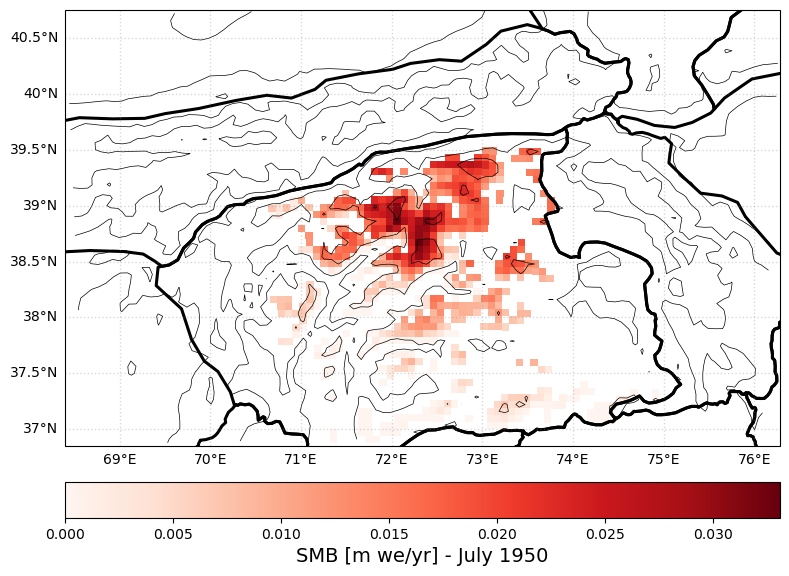

In [43]:
#Test plot

cmap = 'Red'

norm = colors.Normalize(
    vmin=0,
    vmax = ds_SMB_WP.isel(time=1).max().compute().item()
)

fig = plt.figure(figsize=(8, 8))
ax2 = fig.add_subplot(111, projection=ccrs.PlateCarree())

ax2.set_extent([
    LONS_pamir.min(), LONS_pamir.max(),
    LATS_pamir.min(), LATS_pamir.max()
], crs=ccrs.PlateCarree())


# --- DATA ---
CS2 = ax2.pcolormesh(
    LONS_pamir,
    LATS_pamir,
    ds_SMB_WP.isel(time=1),
    cmap="Reds",
    norm=norm,
    transform=ccrs.PlateCarree(),
    shading="auto"
)

# --- CONTOURS ---
ax2.contour(LONS_pamir, LATS_pamir, SH_pamir,
            levels=[1000, 2000, 3000, 4000, 5000, 6000, 7000],
            colors="k", linewidths=0.5,
            transform=ccrs.PlateCarree())

# --- REGIONS ---
regions.boundary.plot(
    ax=ax2,
    edgecolor='black',
    linewidth=2.2,
    transform=ccrs.PlateCarree()
)

# --- GRIDLINES ---
gl = ax2.gridlines(draw_labels=True,
                   linewidth=1, color="gray",
                   alpha=0.3, linestyle=":")
gl.top_labels = False
gl.right_labels = False

# --- COLORBAR ---
cbar = fig.colorbar(CS2, ax=ax2,
                    orientation="horizontal",
                    pad=0.05, fraction=0.05)

cbar.set_label("SMB [m we/yr] - July 1950", fontsize=14)

plt.tight_layout()
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/tmp/ipykernel_387389/1774770435.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


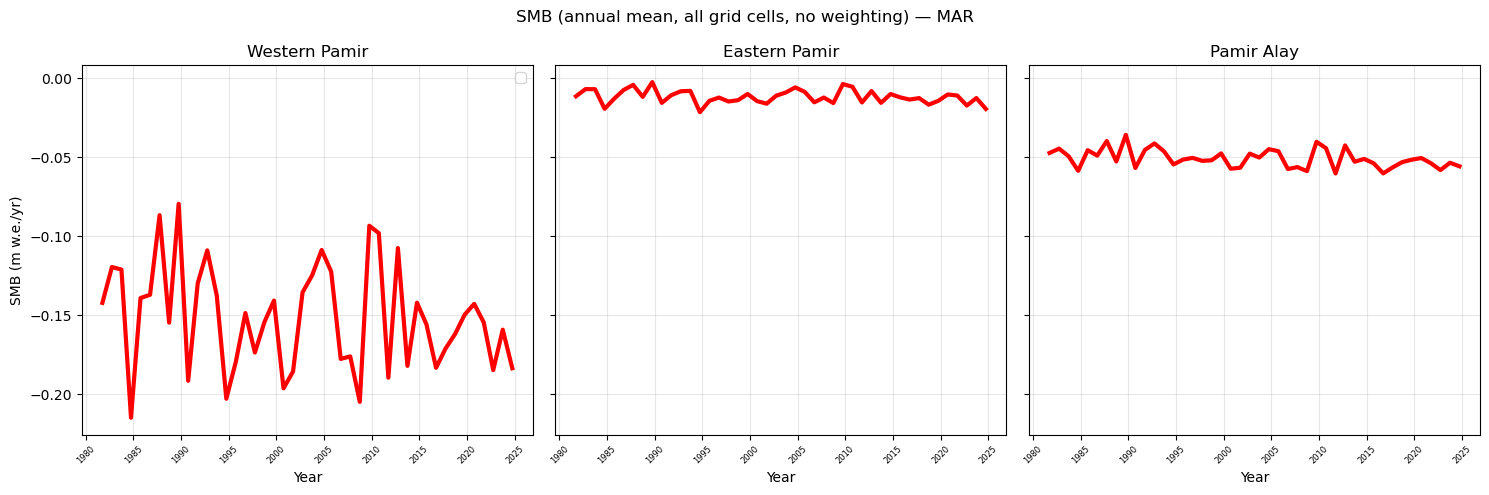

In [44]:
dfs = [ds_SMB_WP, ds_SMB_EP, ds_SMB_PA]
titles = ['Western Pamir', 'Eastern Pamir', 'Pamir Alay']

yr_start = '1980-10-01T12:00:00.000000000'
yr_stop  = '2024-09-30T12:00:00.000000000'

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5),
    sharex=True,
    sharey=True
)

for ax, df, title in zip(axes, dfs, titles):
    smb_annual = (
        df
        .sel(time=slice(yr_start, yr_stop))
        .resample(time="A-SEP")
        .sum()
        .mean(dim=["Y", "X"], skipna=True)
    )
    
    ax.plot(
        smb_annual.time,
        smb_annual,
        color='red',
        lw=3,
    )

    ax.set_title(title)
    ax.set_xlabel('Year')
    ax.tick_params(axis='x', labelsize=6)
    ax.grid(alpha=0.3)


axes[0].set_ylabel('SMB (m w.e./yr)')
axes[0].legend()

plt.suptitle(
    "SMB (annual mean, all grid cells, no weighting) — MAR"
)

for ax in axes:
    ax.tick_params(axis='x', labelrotation=45)

plt.tight_layout()
plt.show()

In [45]:
elev_bins = np.arange(0, np.nanmax(SH_pamir.values.flatten()) + dz, dz)
elev_bin_labels = (elev_bins[:-1] + elev_bins[1:]) / 2

In [46]:
def mean_smb_by_elevation(
    ds_SMB,
    SH,
    yr_start,
    yr_stop,
    elev_bins
):
    # --------------------------------------------------
    # 1. Sélection de la période
    # --------------------------------------------------
    data = ds_SMB.sel(
        time=slice(yr_start, yr_stop)
    )

    # --------------------------------------------------
    # 2. SMB annuel = somme sur chaque année
    # --------------------------------------------------
    data = data.resample(
        time="A-SEP"
    ).sum()

    # --------------------------------------------------
    # 3. Moyenne du SMB annuel sur la période
    # --------------------------------------------------
    data = data.mean(dim="time")

    # --------------------------------------------------
    # 4. Passage en 1D
    # --------------------------------------------------
    elevation = SH.values.flatten()
    smb = data.values.flatten()

    df = pd.DataFrame({
        "elevation": elevation,
        "smb": smb
    })

    # --------------------------------------------------
    # 5. Supprimer les valeurs invalides / nulles
    # --------------------------------------------------
    df = df[
        np.isfinite(df["elevation"]) &
        np.isfinite(df["smb"]) &
        (df["smb"] != 0)
    ]

    # --------------------------------------------------
    # 6. Classes d'altitude
    # --------------------------------------------------
    df["elev_bin"] = pd.cut(
        df["elevation"],
        bins=elev_bins
    )

    # --------------------------------------------------
    # 7. Moyenne + écart-type par altitude
    # --------------------------------------------------
    result = (
        df
        .groupby("elev_bin", observed=True)["smb"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    # Centre de chaque classe
    result["altitude_m"] = result["elev_bin"].apply(
        lambda x: x.mid
    )

    return result

In [47]:
yr_start = "2000-01-16T12:00:00.000000000"
yr_stop = "2008-12-16T12:00:00.000000000"

result_PA = mean_smb_by_elevation(
    ds_SMB_PA,
    SH_pamir,
    yr_start,
    yr_stop,
    elev_bins
)

result_EP = mean_smb_by_elevation(
    ds_SMB_EP,
    SH_pamir,
    yr_start,
    yr_stop,
    elev_bins
)

result_WP = mean_smb_by_elevation(
    ds_SMB_WP,
    SH_pamir,
    yr_start,
    yr_stop,
    elev_bins
)

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(


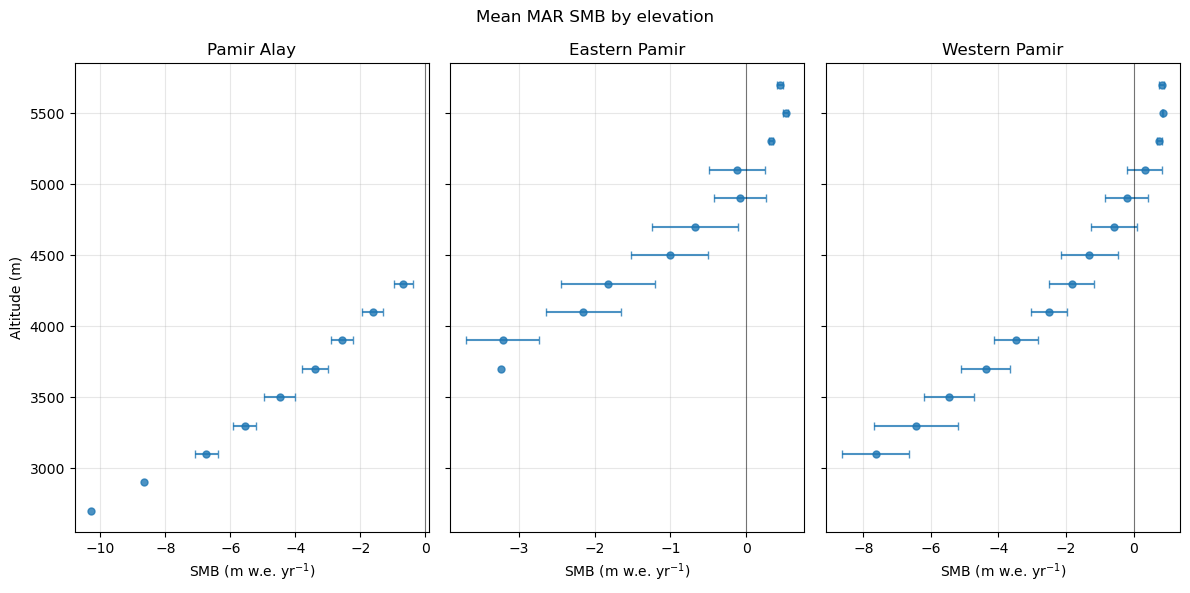

In [48]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 6),
    sharey=True
)

results = [
    result_PA,
    result_EP,
    result_WP
]

titles = [
    "Pamir Alay",
    "Eastern Pamir",
    "Western Pamir"
]

for ax, result, title in zip(axes, results, titles):

    ax.errorbar(
        result["mean"],
        result["altitude_m"],
        xerr=result["std"],
        fmt="o",
        markersize=5,
        capsize=3,
        alpha=0.8
    )

    ax.axvline(
        0,
        color="black",
        linewidth=0.8,
        alpha=0.5
    )

    ax.set_title(title)
    ax.set_xlabel("SMB (m w.e. yr$^{-1}$)")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Altitude (m)")

plt.suptitle(
    "Mean MAR SMB by elevation"
)

plt.tight_layout()
plt.show()

# COMPARE MAR and Remote Sensing Datasets

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(


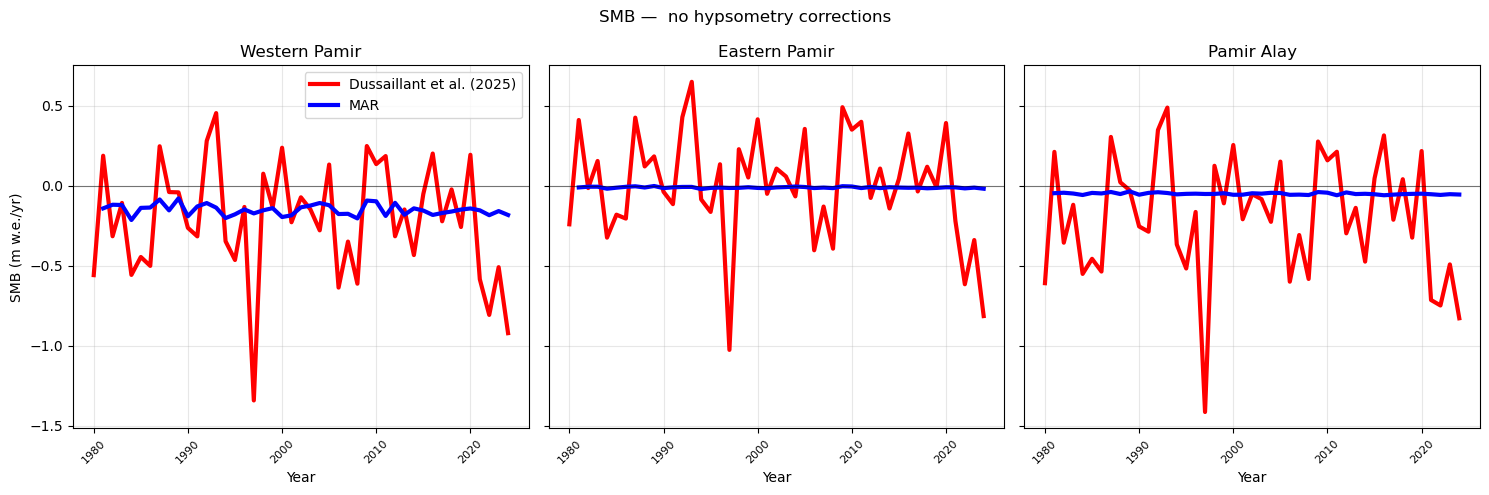

In [49]:
df_remotes_sensing = [dus_df_WP, dus_df_EP, dus_df_PA]
df_mar = [ds_SMB_WP, ds_SMB_EP, ds_SMB_PA]
titles = ['Western Pamir', 'Eastern Pamir', 'Pamir Alay']

yr_start_dus = '1980-10-01T12:00:00.000000000'
yr_stop_dus  = '2024-09-30T12:00:00.000000000'

yr_start = pd.to_datetime(yr_start_dus).year
yr_stop = pd.to_datetime(yr_stop_dus).year

# Années pour sélectionner les colonnes de df_dus
yrs_str = [str(y) for y in range(yr_start, yr_stop + 1)]
# Années pour le graphique
yrs = np.arange(yr_start, yr_stop + 1)


fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5),
    sharex=True,
    sharey=True
)

for ax, title, df, smb_mar in zip(
    axes, titles, df_remotes_sensing, df_mar
):

    # ========================================================
    # Remote Sensing dataset
    # ========================================================
    cum_smb = df[yrs_str]#.cumsum(axis=1)
    weighted_mean_cum = (
        cum_smb.mul(df["area"], axis=0).sum(axis=0)
        / df["area"].sum()
    )

    ax.plot(
        yrs,
        weighted_mean_cum,
        lw=3,
        label="Dussaillant et al. (2025)",
        color = 'red'
    )
    # ========================================================
    # MAR
    # ========================================================
    smb_mar_annual = (
        smb_mar
        .sel(time=slice(yr_start_dus, yr_stop_dus))
        .resample(time="A-SEP")
        .sum()
        .mean(dim=["Y", "X"], skipna=True)
    )

    
    ax.plot(
        smb_mar_annual.time.dt.year.values,
        smb_mar_annual,
        lw=3,
        label="MAR",
        color = 'blue'
    )
 
    # ========================================================
    # MISE EN FORME du PLOT
    # ======================================================== 
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.grid(
        alpha=0.3
    )
    
    ax.axhline(
        0,
        color="black",
        lw=0.8,
        alpha=0.5
    )
    
    ax.tick_params(
        axis="x",
        labelsize=8,
        labelrotation=45
    )

axes[0].set_ylabel(
    "SMB (m w.e./yr)"
)

axes[0].legend()

plt.suptitle(
    "SMB —  no hypsometry corrections"
)

plt.tight_layout()
plt.show()

# Project MAR data on RGI v6 HYPSOMETRIES

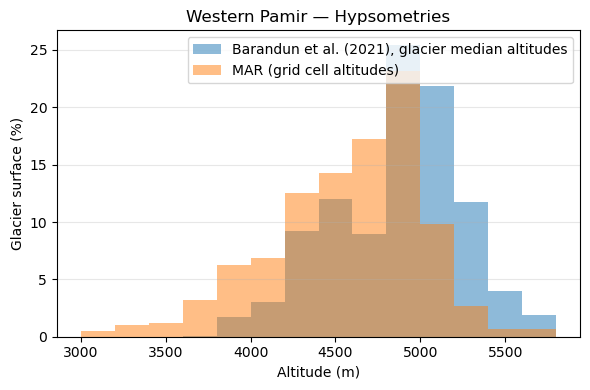

Surface glaciaire totale RGI : 2743.81 km²
Surface glaciaire totale MAR : 7553.20 km²
Somme RGI : 100.00 %
Somme MAR : 100.00 %


In [50]:
# HYPSOMETRIE COMPAREE Barandun et MAR - Western Pamir
# le % de glace MAR est pris en compte pour le calcul de la surface totale de glace 

region_value = 6       # Western Pamir
cell_area = 7 * 7      # km²
df = baran_df_WP.copy()

total_area_rgi = df["area"].sum()

# ============================================================
# 2. MAR / ICE — distribution selon altitude
# ============================================================

# Altitudes du Western Pamir
altitudes = SH_pamir.where(
    (mask == region_value) &
    (ICE_pamir > 0)
)

# Surface glaciaire par cellule
ice_area = ICE_pamir/100 * cell_area

# Garder uniquement Western Pamir + glace
ice_area = ice_area.where(
    (mask == region_value) &
    (ICE_pamir > 0)
)

# Conversion en tableaux 1D
altitudes_flat = altitudes.values.flatten()
ice_area_flat = ice_area.values.flatten()

# Retirer les NaN
valid = (
    np.isfinite(altitudes_flat) &
    np.isfinite(ice_area_flat)
)

altitudes_flat = altitudes_flat[valid]
ice_area_flat = ice_area_flat[valid]

# ============================================================
# 3. Classes d'altitude communes aux deux méthodes
# ============================================================

zmin = np.floor(
    min(df["Zmed"].min(), altitudes_flat.min()) / dz
) * dz

zmax = np.ceil(
    max(df["Zmed"].max(), altitudes_flat.max()) / dz
) * dz

bins = np.arange(zmin, zmax + dz, dz)

z_center = (bins[:-1] + bins[1:]) / 2

# ============================================================
# 4. Barandun et al.
# ============================================================

area_rgi_by_bin, _ = np.histogram(
    df["Zmed"],
    bins=bins,
    weights=df["area"]
)

percentage_rgi = (
    area_rgi_by_bin /
    total_area_rgi
) * 100


# ============================================================
# 5. MAR / ICE — surface par classe d'altitude
# ============================================================

area_mar_by_bin, _ = np.histogram(
    altitudes_flat,
    bins=bins,
    weights=ice_area_flat
)

total_ice_area = area_mar_by_bin.sum()

percentage_mar = (
    area_mar_by_bin /
    total_ice_area
) * 100


# ============================================================
# 6. PLOT COMPARATIF
# ============================================================

plt.figure(figsize=(6, 4))

# RGI 6.0
plt.bar(
    z_center,
    percentage_rgi,
    width=dz,
    align="center",
    alpha=0.5,
    label="Barandun et al. (2021), glacier median altitudes"
)

# MAR / ICE
plt.bar(
    z_center,
    percentage_mar,
    width=dz,
    align="center",
    alpha=0.5,
    label="MAR (grid cell altitudes)"
)

plt.xlabel("Altitude (m)")
plt.ylabel("Glacier surface (%)")
plt.title("Western Pamir — Hypsometries")

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# 7. VÉRIFICATIONS
# ============================================================

print(
    f"Surface glaciaire totale RGI : "
    f"{total_area_rgi:.2f} km²"
)

print(
    f"Surface glaciaire totale MAR : "
    f"{total_ice_area:.2f} km²"
)

print(
    f"Somme RGI : "
    f"{percentage_rgi.sum():.2f} %"
)

print(
    f"Somme MAR : "
    f"{percentage_mar.sum():.2f} %"
)


hypsometry_baran_WP = pd.DataFrame({
    "altitude_m": z_center,
    "percentage_rgi": percentage_rgi
})

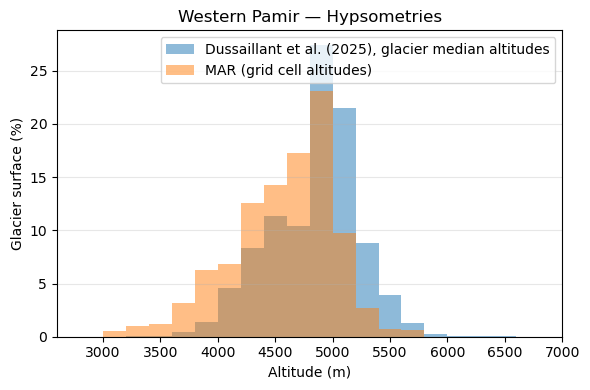

Surface glaciaire totale RGI : 8238.19 km²
Surface glaciaire totale MAR : 7553.20 km²
Somme RGI : 100.00 %
Somme MAR : 100.00 %


In [51]:
# HYPSOMETRIE COMPAREE Dussaillant et MAR - Western Pamir
# le % de glace MAR est pris en compte pour le calcul de la surface totale de glace 

region_value = 6       # Western Pamir
cell_area = 7 * 7      # km²
df = dus_df_WP.copy()

total_area_rgi = df["area"].sum()

# ============================================================
# 2. MAR / ICE — distribution selon altitude
# ============================================================

# Altitudes du Western Pamir
altitudes = SH_pamir.where(
    (mask == region_value) &
    (ICE_pamir > 0)
)

# Surface glaciaire par cellule
ice_area = ICE_pamir/100 * cell_area

# Garder uniquement Western Pamir + glace
ice_area = ice_area.where(
    (mask == region_value) &
    (ICE_pamir > 0)
)

# Conversion en tableaux 1D
altitudes_flat = altitudes.values.flatten()
ice_area_flat = ice_area.values.flatten()

# Retirer les NaN
valid = (
    np.isfinite(altitudes_flat) &
    np.isfinite(ice_area_flat)
)

altitudes_flat = altitudes_flat[valid]
ice_area_flat = ice_area_flat[valid]

# ============================================================
# 3. Classes d'altitude communes aux deux méthodes
# ============================================================

zmin = np.floor(
    min(df["Zmed"].min(), altitudes_flat.min()) / dz
) * dz

zmax = np.ceil(
    max(df["Zmed"].max(), altitudes_flat.max()) / dz
) * dz

bins = np.arange(zmin, zmax + dz, dz)

z_center = (bins[:-1] + bins[1:]) / 2

# ============================================================
# 4. Dussaillant et al.
# ============================================================

area_rgi_by_bin, _ = np.histogram(
    df["Zmed"],
    bins=bins,
    weights=df["area"]
)

percentage_rgi = (
    area_rgi_by_bin /
    total_area_rgi
) * 100


# ============================================================
# 5. MAR / ICE — surface par classe d'altitude
# ============================================================

area_mar_by_bin, _ = np.histogram(
    altitudes_flat,
    bins=bins,
    weights=ice_area_flat
)

total_ice_area = area_mar_by_bin.sum()

percentage_mar = (
    area_mar_by_bin /
    total_ice_area
) * 100


# ============================================================
# 6. PLOT COMPARATIF
# ============================================================

plt.figure(figsize=(6, 4))

# RGI 6.0
plt.bar(
    z_center,
    percentage_rgi,
    width=dz,
    align="center",
    alpha=0.5,
    label="Dussaillant et al. (2025), glacier median altitudes"
)

# MAR / ICE
plt.bar(
    z_center,
    percentage_mar,
    width=dz,
    align="center",
    alpha=0.5,
    label="MAR (grid cell altitudes)"
)

plt.xlabel("Altitude (m)")
plt.ylabel("Glacier surface (%)")
plt.title("Western Pamir — Hypsometries")

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# 7. VÉRIFICATIONS
# ============================================================

print(
    f"Surface glaciaire totale RGI : "
    f"{total_area_rgi:.2f} km²"
)

print(
    f"Surface glaciaire totale MAR : "
    f"{total_ice_area:.2f} km²"
)

print(
    f"Somme RGI : "
    f"{percentage_rgi.sum():.2f} %"
)

print(
    f"Somme MAR : "
    f"{percentage_mar.sum():.2f} %"
)


hypsometry_dus_WP = pd.DataFrame({
    "altitude_m": z_center,
    "percentage_rgi": percentage_rgi
})

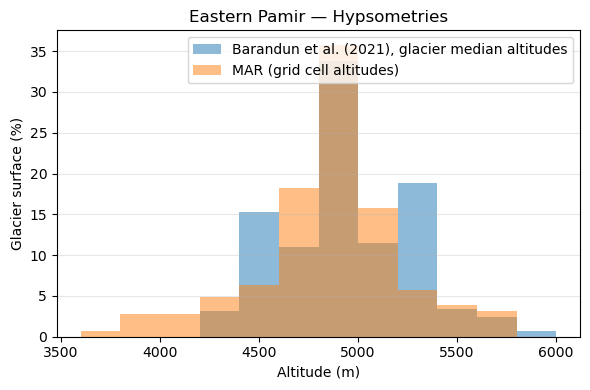

Surface glaciaire totale RGI : 618.87 km²
Surface glaciaire totale MAR : 1070.30 km²
Somme RGI : 100.00 %
Somme MAR : 100.00 %


In [52]:
# HYPSOMETRIE COMPAREE Barandun et MAR - EASTERN Pamir

region_value = 7       # Eastern Pamir
cell_area = 7 * 7      # km²

# ============================================================
# 1. Barandun et al.
# ============================================================

df = baran_df_EP.copy()

# Surface glaciaire totale RGI
total_area_rgi = df["area"].sum()

# ============================================================
# 2. MAR / ICE — distribution selon altitude
# ============================================================

# Altitudes du Western Pamir
altitudes = SH_pamir.where(
    (mask == region_value) &
    (ICE_pamir > 0)
)



# Surface glaciaire par cellule
ice_area = ICE_pamir/100 * cell_area

# Garder uniquement Western Pamir + glace
ice_area = ice_area.where(
    (mask == region_value) &
    (ICE_pamir > 0)
)

# Conversion en tableaux 1D
altitudes_flat = altitudes.values.flatten()
ice_area_flat = ice_area.values.flatten()

# Retirer les NaN
valid = (
    np.isfinite(altitudes_flat) &
    np.isfinite(ice_area_flat)
)

altitudes_flat = altitudes_flat[valid]
ice_area_flat = ice_area_flat[valid]

# ============================================================
# 3. Classes d'altitude communes aux deux méthodes
# ============================================================

zmin = np.floor(
    min(df["Zmed"].min(), altitudes_flat.min()) / dz
) * dz

zmax = np.ceil(
    max(df["Zmed"].max(), altitudes_flat.max()) / dz
) * dz

bins = np.arange(zmin, zmax + dz, dz)

z_center = (bins[:-1] + bins[1:]) / 2


# ============================================================
# 4. RGI — surface par classe de Zmed
# ============================================================

area_rgi_by_bin, _ = np.histogram(
    df["Zmed"],
    bins=bins,
    weights=df["area"]
)

percentage_rgi = (
    area_rgi_by_bin /
    total_area_rgi
) * 100


# ============================================================
# 5. MAR / ICE — surface par classe d'altitude
# ============================================================

area_mar_by_bin, _ = np.histogram(
    altitudes_flat,
    bins=bins,
    weights=ice_area_flat
)

total_ice_area = area_mar_by_bin.sum()

percentage_mar = (
    area_mar_by_bin /
    total_ice_area
) * 100


# ============================================================
# 6. PLOT COMPARATIF
# ============================================================

plt.figure(figsize=(6, 4))

# RGI 6.0
plt.bar(
    z_center,
    percentage_rgi,
    width=dz,
    align="center",
    alpha=0.5,
    label="Barandun et al. (2021), glacier median altitudes"
)

# MAR / ICE
plt.bar(
    z_center,
    percentage_mar,
    width=dz,
    align="center",
    alpha=0.5,
    label="MAR (grid cell altitudes)"
)

plt.xlabel("Altitude (m)")
plt.ylabel("Glacier surface (%)")
plt.title("Eastern Pamir — Hypsometries")

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# 7. VÉRIFICATIONS
# ============================================================

print(
    f"Surface glaciaire totale RGI : "
    f"{total_area_rgi:.2f} km²"
)

print(
    f"Surface glaciaire totale MAR : "
    f"{total_ice_area:.2f} km²"
)

print(
    f"Somme RGI : "
    f"{percentage_rgi.sum():.2f} %"
)

print(
    f"Somme MAR : "
    f"{percentage_mar.sum():.2f} %"
)


hypsometry_baran_EP = pd.DataFrame({
    "altitude_m": z_center,
    "percentage_rgi": percentage_rgi
})

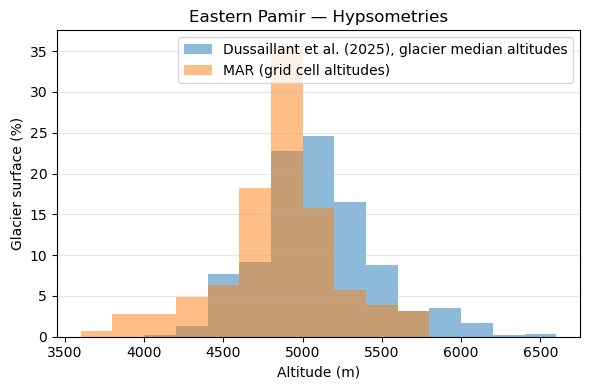

Surface glaciaire totale RGI : 1995.41 km²
Surface glaciaire totale MAR : 1070.30 km²
Somme RGI : 100.00 %
Somme MAR : 100.00 %


In [53]:
# HYPSOMETRIE COMPAREE Dussaillant et MAR - EASTERN Pamir

region_value = 7       # Eastern Pamir
cell_area = 7 * 7      # km²

# ============================================================
# 1. RGI 6.0 — distribution selon Zmed
# ============================================================

df = dus_df_EP.copy()
#df = df.rename(columns={"Zmed_x": "Zmed"})

# Surface glaciaire totale RGI
total_area_rgi = df["area"].sum()

# ============================================================
# 2. MAR / ICE — distribution selon altitude
# ============================================================

# Altitudes du Western Pamir
altitudes = SH_pamir.where(
    (mask == region_value) &
    (ICE_pamir > 0)
)



# Surface glaciaire par cellule
ice_area = ICE_pamir/100 * cell_area

# Garder uniquement Western Pamir + glace
ice_area = ice_area.where(
    (mask == region_value) &
    (ICE_pamir > 0)
)

# Conversion en tableaux 1D
altitudes_flat = altitudes.values.flatten()
ice_area_flat = ice_area.values.flatten()

# Retirer les NaN
valid = (
    np.isfinite(altitudes_flat) &
    np.isfinite(ice_area_flat)
)

altitudes_flat = altitudes_flat[valid]
ice_area_flat = ice_area_flat[valid]

# ============================================================
# 3. Classes d'altitude communes aux deux méthodes
# ============================================================

zmin = np.floor(
    min(df["Zmed"].min(), altitudes_flat.min()) / dz
) * dz

zmax = np.ceil(
    max(df["Zmed"].max(), altitudes_flat.max()) / dz
) * dz

bins = np.arange(zmin, zmax + dz, dz)

z_center = (bins[:-1] + bins[1:]) / 2


# ============================================================
# 4. RGI — surface par classe de Zmed
# ============================================================

area_rgi_by_bin, _ = np.histogram(
    df["Zmed"],
    bins=bins,
    weights=df["area"]
)

percentage_rgi = (
    area_rgi_by_bin /
    total_area_rgi
) * 100


# ============================================================
# 5. MAR / ICE — surface par classe d'altitude
# ============================================================

area_mar_by_bin, _ = np.histogram(
    altitudes_flat,
    bins=bins,
    weights=ice_area_flat
)

total_ice_area = area_mar_by_bin.sum()

percentage_mar = (
    area_mar_by_bin /
    total_ice_area
) * 100


# ============================================================
# 6. PLOT COMPARATIF
# ============================================================

plt.figure(figsize=(6, 4))

# RGI 6.0
plt.bar(
    z_center,
    percentage_rgi,
    width=dz,
    align="center",
    alpha=0.5,
    label="Dussaillant et al. (2025), glacier median altitudes"
)

# MAR / ICE
plt.bar(
    z_center,
    percentage_mar,
    width=dz,
    align="center",
    alpha=0.5,
    label="MAR (grid cell altitudes)"
)

plt.xlabel("Altitude (m)")
plt.ylabel("Glacier surface (%)")
plt.title("Eastern Pamir — Hypsometries")

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# 7. VÉRIFICATIONS
# ============================================================

print(
    f"Surface glaciaire totale RGI : "
    f"{total_area_rgi:.2f} km²"
)

print(
    f"Surface glaciaire totale MAR : "
    f"{total_ice_area:.2f} km²"
)

print(
    f"Somme RGI : "
    f"{percentage_rgi.sum():.2f} %"
)

print(
    f"Somme MAR : "
    f"{percentage_mar.sum():.2f} %"
)


hypsometry_dus_EP = pd.DataFrame({
    "altitude_m": z_center,
    "percentage_rgi": percentage_rgi
})

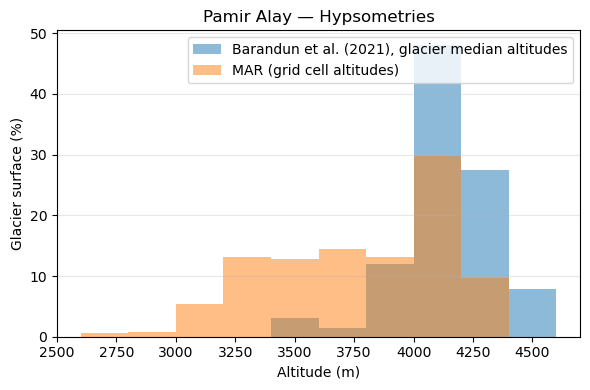

Surface glaciaire totale RGI : 579.33 km²
Surface glaciaire totale MAR : 731.04 km²
Somme RGI : 100.00 %
Somme MAR : 100.00 %


In [54]:
# HYPSOMETRIE COMPAREE Barandun et MAR - Pamir ALAY

region_value = 5       # Pamir Alay
cell_area = 7 * 7      # km²
df = baran_df_PA.copy()

# ============================================================
# 1. RGI 6.0 — distribution selon Zmed
# ============================================================
# Surface glaciaire totale RGI
total_area_rgi = df["area"].sum()

# ============================================================
# 2. MAR / ICE — distribution selon altitude
# ============================================================

# Altitudes du Western Pamir
altitudes = SH_pamir.where(
    (mask == region_value) &
    (ICE_pamir > 0)
)

# Surface glaciaire par cellule
ice_area = ICE_pamir/100 * cell_area

# Garder uniquement Western Pamir + glace
ice_area = ice_area.where(
    (mask == region_value) &
    (ICE_pamir > 0)
)

# Conversion en tableaux 1D
altitudes_flat = altitudes.values.flatten()
ice_area_flat = ice_area.values.flatten()

# Retirer les NaN
valid = (
    np.isfinite(altitudes_flat) &
    np.isfinite(ice_area_flat)
)

altitudes_flat = altitudes_flat[valid]
ice_area_flat = ice_area_flat[valid]

# ============================================================
# 3. Classes d'altitude communes aux deux méthodes
# ============================================================

zmin = np.floor(
    min(df["Zmed"].min(), altitudes_flat.min()) / dz
) * dz

zmax = np.ceil(
    max(df["Zmed"].max(), altitudes_flat.max()) / dz
) * dz

bins = np.arange(zmin, zmax + dz, dz)

z_center = (bins[:-1] + bins[1:]) / 2


# ============================================================
# 4. Barandun et al.
# ============================================================

area_rgi_by_bin, _ = np.histogram(
    df["Zmed"],
    bins=bins,
    weights=df["area"]
)

percentage_rgi = (
    area_rgi_by_bin /
    total_area_rgi
) * 100


# ============================================================
# 5. MAR / ICE — surface par classe d'altitude
# ============================================================

area_mar_by_bin, _ = np.histogram(
    altitudes_flat,
    bins=bins,
    weights=ice_area_flat
)

total_ice_area = area_mar_by_bin.sum()

percentage_mar = (
    area_mar_by_bin /
    total_ice_area
) * 100


# ============================================================
# 6. PLOT
# ============================================================

plt.figure(figsize=(6, 4))

# RGI 6.0
plt.bar(
    z_center,
    percentage_rgi,
    width=dz,
    align="center",
    alpha=0.5,
    label="Barandun et al. (2021), glacier median altitudes"
)

# MAR / ICE
plt.bar(
    z_center,
    percentage_mar,
    width=dz,
    align="center",
    alpha=0.5,
    label="MAR (grid cell altitudes)"
)

plt.xlabel("Altitude (m)")
plt.ylabel("Glacier surface (%)")
plt.title("Pamir Alay — Hypsometries")

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# 7. VÉRIFICATIONS
# ============================================================

print(
    f"Surface glaciaire totale RGI : "
    f"{total_area_rgi:.2f} km²"
)

print(
    f"Surface glaciaire totale MAR : "
    f"{total_ice_area:.2f} km²"
)

print(
    f"Somme RGI : "
    f"{percentage_rgi.sum():.2f} %"
)

print(
    f"Somme MAR : "
    f"{percentage_mar.sum():.2f} %"
)

hypsometry_baran_PA = pd.DataFrame({
    "altitude_m": z_center,
    "percentage_rgi": percentage_rgi
})

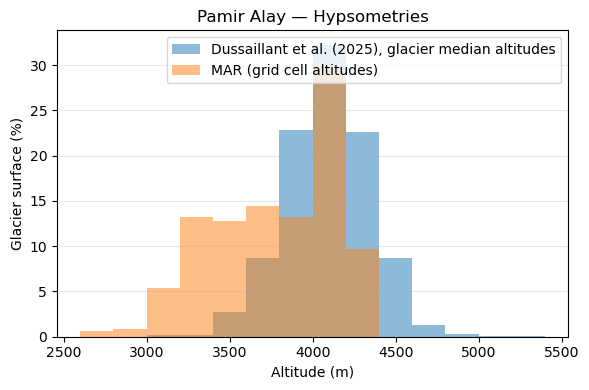

Surface glaciaire totale RGI : 1846.04 km²
Surface glaciaire totale MAR : 731.04 km²
Somme RGI : 100.00 %
Somme MAR : 100.00 %


In [55]:
# HYPSOMETRIE COMPAREE Dussaillant et MAR - Pamir ALAY

region_value = 5       # Pamir Alay
cell_area = 7 * 7      # km²
df = dus_df_PA.copy()

# ============================================================
# 1. RGI 6.0 — distribution selon Zmed
# ============================================================
# Surface glaciaire totale RGI
total_area_rgi = df["area"].sum()

# ============================================================
# 2. MAR / ICE — distribution selon altitude
# ============================================================

# Altitudes du Western Pamir
altitudes = SH_pamir.where(
    (mask == region_value) &
    (ICE_pamir > 0)
)

# Surface glaciaire par cellule
ice_area = ICE_pamir/100 * cell_area

# Garder uniquement Western Pamir + glace
ice_area = ice_area.where(
    (mask == region_value) &
    (ICE_pamir > 0)
)

# Conversion en tableaux 1D
altitudes_flat = altitudes.values.flatten()
ice_area_flat = ice_area.values.flatten()

# Retirer les NaN
valid = (
    np.isfinite(altitudes_flat) &
    np.isfinite(ice_area_flat)
)

altitudes_flat = altitudes_flat[valid]
ice_area_flat = ice_area_flat[valid]

# ============================================================
# 3. Classes d'altitude communes aux deux méthodes
# ============================================================

zmin = np.floor(
    min(df["Zmed"].min(), altitudes_flat.min()) / dz
) * dz

zmax = np.ceil(
    max(df["Zmed"].max(), altitudes_flat.max()) / dz
) * dz

bins = np.arange(zmin, zmax + dz, dz)

z_center = (bins[:-1] + bins[1:]) / 2


# ============================================================
# 4. Dussaillant el al.
# ============================================================

area_rgi_by_bin, _ = np.histogram(
    df["Zmed"],
    bins=bins,
    weights=df["area"]
)

percentage_rgi = (
    area_rgi_by_bin /
    total_area_rgi
) * 100


# ============================================================
# 5. MAR / ICE — surface par classe d'altitude
# ============================================================

area_mar_by_bin, _ = np.histogram(
    altitudes_flat,
    bins=bins,
    weights=ice_area_flat
)

total_ice_area = area_mar_by_bin.sum()

percentage_mar = (
    area_mar_by_bin /
    total_ice_area
) * 100


# ============================================================
# 6. PLOT
# ============================================================

plt.figure(figsize=(6, 4))

# RGI 6.0
plt.bar(
    z_center,
    percentage_rgi,
    width=dz,
    align="center",
    alpha=0.5,
    label="Dussaillant et al. (2025), glacier median altitudes"
)

# MAR / ICE
plt.bar(
    z_center,
    percentage_mar,
    width=dz,
    align="center",
    alpha=0.5,
    label="MAR (grid cell altitudes)"
)

plt.xlabel("Altitude (m)")
plt.ylabel("Glacier surface (%)")
plt.title("Pamir Alay — Hypsometries")

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# 7. VÉRIFICATIONS
# ============================================================

print(
    f"Surface glaciaire totale RGI : "
    f"{total_area_rgi:.2f} km²"
)

print(
    f"Surface glaciaire totale MAR : "
    f"{total_ice_area:.2f} km²"
)

print(
    f"Somme RGI : "
    f"{percentage_rgi.sum():.2f} %"
)

print(
    f"Somme MAR : "
    f"{percentage_mar.sum():.2f} %"
)

hypsometry_dus_PA = pd.DataFrame({
    "altitude_m": z_center,
    "percentage_rgi": percentage_rgi
})

### l'info SMB MAR donnée à des altitudes non représentées par RGI est "perdue"

### Calcul de MAR projeté sur hypsométrie

In [56]:
def smb_MAR_rgi_projection(ds_SMB, SH, hyps_rgi, yr_start, yr_stop, dz):

    # ============================================================
    # 1. MAR
    # ============================================================

    ds = (
        ds_SMB
        .sel(time=slice(yr_start, yr_stop))
        .resample(time="A-SEP")
        .sum()
    )

    # ============================================================
    # 2. Hypsométrie RGI
    # ============================================================

    altitude_rgi = hyps_rgi["altitude_m"].values
    percentage_rgi = hyps_rgi["percentage_rgi"].values

    # ============================================================
    # 3. Classes d'altitude
    # ============================================================

    bins = np.arange(
        altitude_rgi.min() - dz / 2,
        altitude_rgi.max() + dz / 2 + dz,
        dz
    )

    # ============================================================
    # 4. SMB moyen par classe d'altitude
    # ============================================================

    smb_by_bin = (
        ds
        .groupby_bins(SH, bins=bins)
        .mean(
            dim="stacked_Y_X",
            skipna=True
        )
    )

    # ============================================================
    # 5. SMB moyen pondéré par l'hypsométrie
    # ============================================================

    smb_rgi = (
        smb_by_bin * (percentage_rgi / 100)
    ).sum(
        dim="SH_bins",
        skipna=True
    )

    return smb_rgi

### Projecting MAR SMB on Dussaillant Hypsométries

In [57]:
# Projecting MAR SMB on Dussaillant Hypsométries

yr_start_dus = '1980-01-16T12:00:00.000000000'
yr_stop_dus  = '2024-12-16T12:00:00.000000000'

smb_mar_WP_dus = smb_MAR_rgi_projection(
    ds_SMB_WP,
    SH_pamir,
    hypsometry_dus_WP,
    yr_start_dus,
    yr_stop_dus,
    dz
)

smb_mar_EP_dus = smb_MAR_rgi_projection(
    ds_SMB_EP,
    SH_pamir,
    hypsometry_dus_EP,
    yr_start_dus,
    yr_stop_dus,
    dz
)


smb_mar_PA_dus = smb_MAR_rgi_projection(
    ds_SMB_PA,
    SH_pamir,
    hypsometry_dus_PA,
    yr_start_dus,
    yr_stop_dus,
    dz
)

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/dask/array/core.py:4849: PerformanceWarning: Increasing number of chunks by factor of 20
  result = blockwise(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/dask/array/core.py:4849: PerformanceWarning: Increasing number of chunks by factor of 15
  result = blockwise(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP'

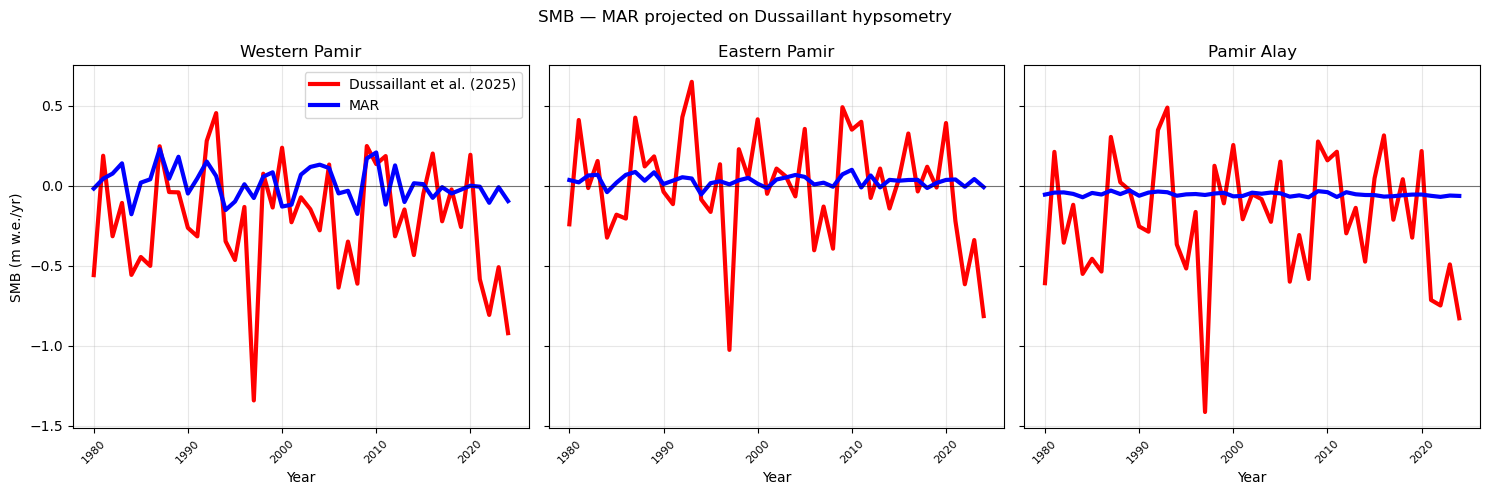

In [58]:
df_remotes_sensing = [dus_df_WP, dus_df_EP, dus_df_PA]
df_mar = [smb_mar_WP_dus, smb_mar_EP_dus, smb_mar_PA_dus]
titles = ['Western Pamir', 'Eastern Pamir', 'Pamir Alay']

yr_start = pd.to_datetime(yr_start_dus).year
yr_stop = pd.to_datetime(yr_stop_dus).year

# Années pour sélectionner les colonnes de df_dus
yrs_str = [str(y) for y in range(yr_start, yr_stop + 1)]
# Années pour le graphique
yrs = np.arange(yr_start, yr_stop + 1)


fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5),
    sharex=True,
    sharey=True
)


for ax, title, df, smb_mar in zip(
    axes, titles, df_remotes_sensing, df_mar
):

    # ========================================================
    # Remote Sensing dataset
    # ========================================================
    cum_smb = df[yrs_str]#.cumsum(axis=1)
    weighted_mean_cum = (
        cum_smb.mul(df["area"], axis=0).sum(axis=0)
        / df["area"].sum()
    )

    ax.plot(
        yrs,
        weighted_mean_cum,
        lw=3,
        label="Dussaillant et al. (2025)",
        color = 'red'
    )

    # ========================================================
    # MAR
    # ========================================================
    smb_mar_sel = smb_mar.sel(
        time=smb_mar.time.dt.year.isin(
            range(yr_start, yr_stop + 1)
        )
    )
    smb_mar_cum = smb_mar_sel#.cumsum(dim="time")
    
    ax.plot(
        smb_mar_cum.time.dt.year.values,
        smb_mar_cum,
        lw=3,
        label="MAR",
        color = 'blue'
    )
    
    # ========================================================
    # MISE EN FORME du PLOT
    # ======================================================== 
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.grid(
        alpha=0.3
    )
    
    ax.axhline(
        0,
        color="black",
        lw=0.8,
        alpha=0.5
    )
    
    ax.tick_params(
        axis="x",
        labelsize=8,
        labelrotation=45
    )

axes[0].set_ylabel(
    "SMB (m w.e./yr)"
)

axes[0].legend()

plt.suptitle(
    "SMB — MAR projected on Dussaillant hypsometry"
)

plt.tight_layout()
plt.show()

In [75]:
# Calcul SMB par décénnie MAR et Dussaillant + biais

df_remotes_sensing = [dus_df_WP, dus_df_EP, dus_df_PA]
df_mar = [smb_mar_WP_dus, smb_mar_EP_dus, smb_mar_PA_dus]
titles = ['Western Pamir', 'Eastern Pamir', 'Pamir Alay']

yr_start = pd.to_datetime(yr_start_dus).year
yr_stop = pd.to_datetime(yr_stop_dus).year

yrs = np.arange(yr_start, yr_stop + 1)
yrs_str = [str(y) for y in yrs]

decadal_results = []

for title, df, smb_mar in zip(titles, df_remotes_sensing, df_mar):

    # Remote sensing
    smb_rs = (
        df[yrs_str]
        .mul(df["area"], axis=0)
        .sum(axis=0)
        / df["area"].sum()
    )

    smb_rs.index = yrs

    # MAR 
    smb_mar = smb_mar.sel(
        time=smb_mar.time.dt.year.isin(yrs)
    )

    smb_mar_series = pd.Series(
        smb_mar.values,
        index=smb_mar.time.dt.year.values
    )

    # Décennies
    decades = (yrs // 10) * 10

    for decade in np.unique(decades):

        mask = decades == decade

        sum_rs = smb_rs.iloc[mask].sum()
        sum_mar = smb_mar_series.iloc[mask].sum()

        decadal_results.append({
            "Massif": title,
            "Decade": f"{decade}s",
            "SMB_rs": sum_rs,
            "SMB_MAR": sum_mar,
            "Difference_MAR_minus_rs": sum_mar - sum_rs,
            "N_years": mask.sum()
        })

df_decadal_dus = pd.DataFrame(decadal_results)

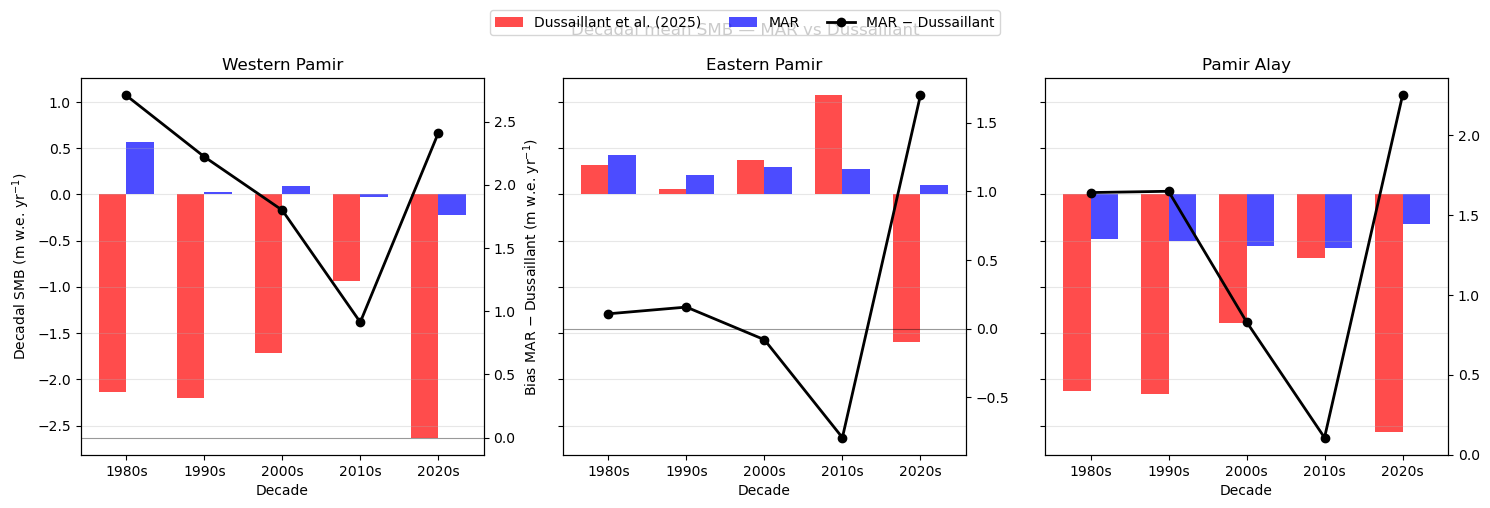

In [76]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5),
    sharey=True
)

ax_diffs = []

for ax, title in zip(axes, titles):

    data = df_decadal_dus[
        df_decadal_dus["Massif"] == title
    ].copy()

    x = np.arange(len(data))
    width = 0.35

    # ========================================================
    # Remote Sensing
    # ========================================================
    ax.bar(
        x - width / 2,
        data["SMB_rs"],
        width=width,
        color="red",
        alpha=0.7,
        label="Dussaillant et al. (2025)"
    )

    # ========================================================
    # SMB MAR
    # ========================================================
    ax.bar(
        x + width / 2,
        data["SMB_MAR"],
        width=width,
        color="blue",
        alpha=0.7,
        label="MAR"
    )

    # ========================================================
    # Axe secondaire pour le biais
    # ========================================================
    ax_diff = ax.twinx()
    ax_diffs.append(ax_diff)

    ax_diff.plot(
        x,
        data["Difference_MAR_minus_rs"],
        color="black",
        marker="o",
        linewidth=2,
        label="MAR − Dussaillant"
    )

    ax_diff.axhline(
        0,
        color="black",
        linewidth=0.8,
        alpha=0.4
    )

    # ========================================================
    # Mise en forme
    # ========================================================
    ax.set_title(title)

    ax.set_xticks(x)
    ax.set_xticklabels(data["Decade"])

    ax.set_xlabel("Decade")

    ax.grid(
        axis="y",
        alpha=0.3
    )

# Axe gauche uniquement sur le premier panneau
axes[0].set_ylabel(
    "Decadal SMB (m w.e. yr$^{-1}$)"
)

# Axe droit
ax_diffs[0].set_ylabel(
    "Bias MAR − Dussaillant (m w.e. yr$^{-1}$)"
)

# ============================================================
# Légende commune
# ============================================================

handles1, labels1 = axes[0].get_legend_handles_labels()

handles2, labels2 = ax_diffs[0].get_legend_handles_labels()

fig.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.02)
)

plt.suptitle(
    "Decadal mean SMB — MAR vs Dussaillant"
)

plt.tight_layout()

plt.show()

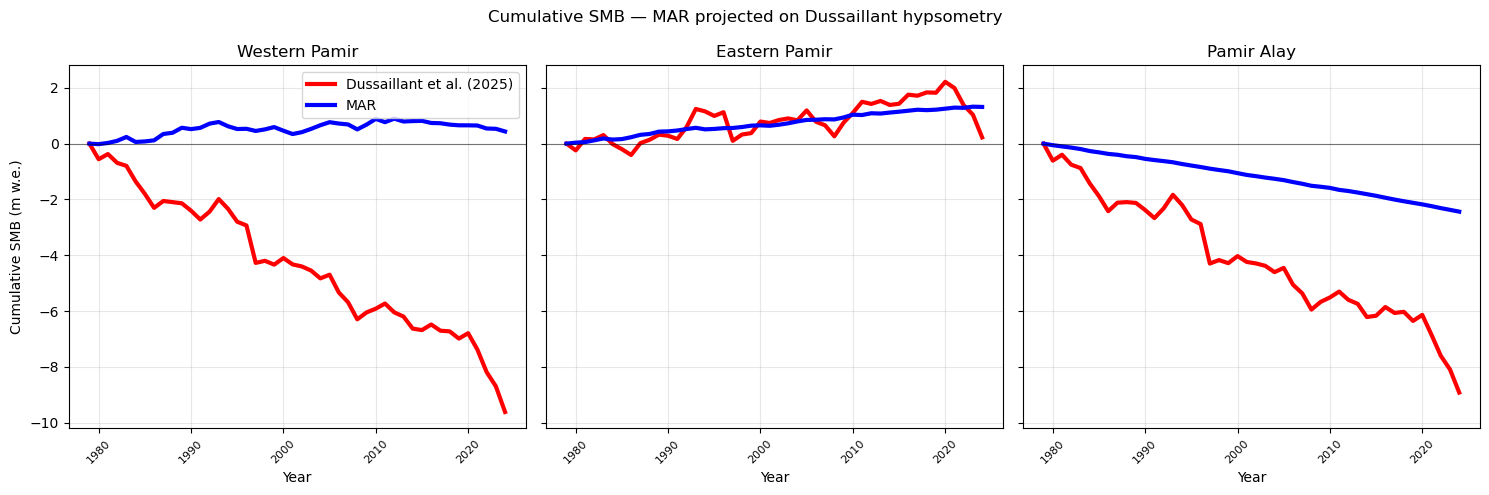

In [61]:
df_remotes_sensing = [dus_df_WP, dus_df_EP, dus_df_PA]
df_mar = [smb_mar_WP_dus, smb_mar_EP_dus, smb_mar_PA_dus]
titles = ['Western Pamir', 'Eastern Pamir', 'Pamir Alay']

yr_start = pd.to_datetime(yr_start_dus).year
yr_stop = pd.to_datetime(yr_stop_dus).year

# Années pour sélectionner les colonnes de df_dus
yrs_str = [str(y) for y in range(yr_start, yr_stop + 1)]
# Années pour le graphique
yrs = np.arange(yr_start, yr_stop + 1)


fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5),
    sharex=True,
    sharey=True
)


for ax, title, df, smb_mar in zip(
    axes, titles, df_remotes_sensing, df_mar
):

    # ========================================================
    # Remote Sensing dataset
    # ========================================================
    cum_smb = df[yrs_str].cumsum(axis=1)
    weighted_mean_cum = (
        cum_smb.mul(df["area"], axis=0).sum(axis=0)
        / df["area"].sum()
    )
    # Ajouter un point initial à zéro
    yrs_plot = np.insert(yrs, 0, yr_start - 1)
    weighted_mean_cum_plot = np.insert(
        weighted_mean_cum.values,
        0,
        0
    )

    ax.plot(
        yrs_plot,
        weighted_mean_cum_plot,
        lw=3,
        label="Dussaillant et al. (2025)",
        color = 'red'
    )

    # ========================================================
    # MAR
    # ========================================================
    smb_mar_sel = smb_mar.sel(
        time=smb_mar.time.dt.year.isin(
            range(yr_start, yr_stop + 1)
        )
    )
    smb_mar_cum = smb_mar_sel.cumsum(dim="time")
    
    # Ajouter un point initial à zéro
    mar_years_plot = np.insert(
        smb_mar_cum.time.dt.year.values,
        0,
        yr_start - 1
    )
    smb_mar_cum_plot = np.insert(
        smb_mar_cum.values,
        0,
        0
    )

    ax.plot(
        mar_years_plot,
        smb_mar_cum_plot,
        lw=3,
        label="MAR",
        color = 'blue'
    )
    
    # ========================================================
    # MISE EN FORME du PLOT
    # ======================================================== 
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.grid(
        alpha=0.3
    )
    
    ax.axhline(
        0,
        color="black",
        lw=0.8,
        alpha=0.5
    )
    
    ax.tick_params(
        axis="x",
        labelsize=8,
        labelrotation=45
    )

axes[0].set_ylabel(
    "Cumulative SMB (m w.e.)"
)

axes[0].legend()

plt.suptitle(
    "Cumulative SMB — MAR projected on Dussaillant hypsometry"
)

plt.tight_layout()
plt.show()

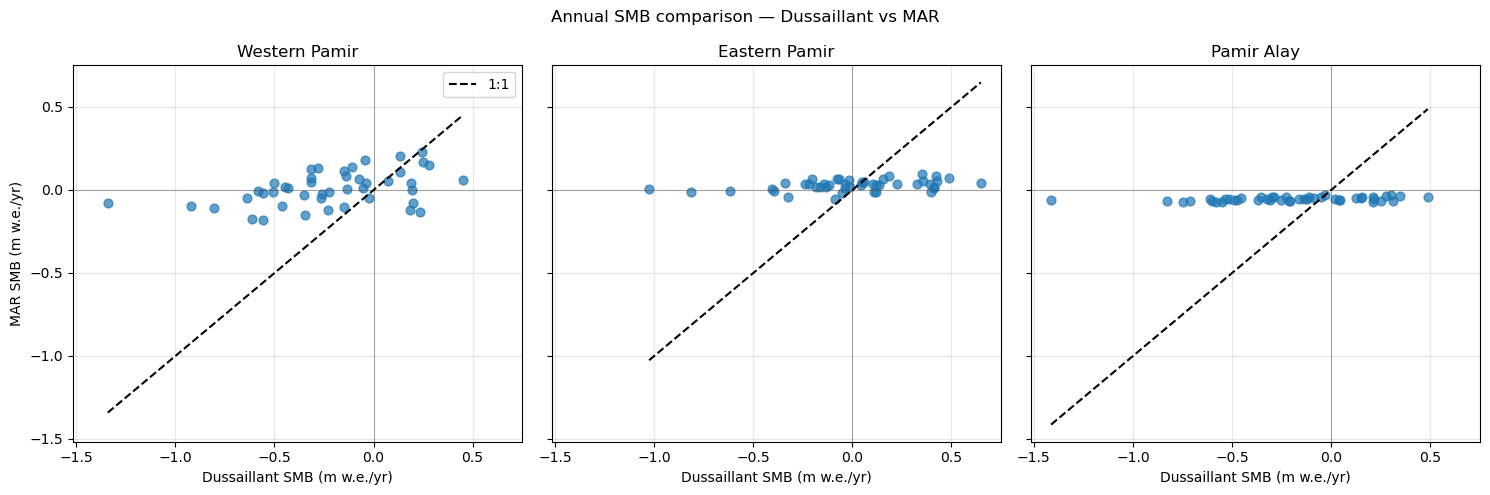

In [66]:
df_remotes_sensing = [dus_df_WP, dus_df_EP, dus_df_PA]
df_mar = [smb_mar_WP_dus, smb_mar_EP_dus, smb_mar_PA_dus]
titles = ['Western Pamir', 'Eastern Pamir', 'Pamir Alay']

yr_start = pd.to_datetime(yr_start_dus).year
yr_stop = pd.to_datetime(yr_stop_dus).year

# Années
yrs_str = [str(y) for y in range(yr_start, yr_stop + 1)]


fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5),
    sharex=True,
    sharey=True
)


for ax, title, df, smb_mar in zip(
    axes, titles, df_remotes_sensing, df_mar
):

    # ========================================================
    # Dussaillant et al. (2025)
    # ========================================================

    smb_dus = (
        df[yrs_str]
        .mul(df["area"], axis=0)
        .sum(axis=0)
        / df["area"].sum()
    )

    # ========================================================
    # MAR
    # ========================================================

    smb_mar_sel = smb_mar.sel(
        time=smb_mar.time.dt.year.isin(
            range(yr_start, yr_stop + 1)
        )
    )

    # ========================================================
    # Scatter plot
    # ========================================================

    ax.scatter(
        smb_dus,
        smb_mar_sel,
        s=40,
        alpha=0.7,
    )

    # ========================================================
    # Ligne 1:1
    # ========================================================

    xmin = min(smb_dus.min(), smb_mar_sel.min())
    xmax = max(smb_dus.max(), smb_mar_sel.max())

    ax.plot(
        [xmin, xmax],
        [xmin, xmax],
        color="black",
        linestyle="--",
        lw=1.5,
        label="1:1"
    )

    # ========================================================
    # Mise en forme
    # ========================================================

    ax.set_title(title)
    ax.set_xlabel("Dussaillant SMB (m w.e./yr)")
    ax.grid(alpha=0.3)

    ax.axhline(
        0,
        color="black",
        lw=0.8,
        alpha=0.3
    )

    ax.axvline(
        0,
        color="black",
        lw=0.8,
        alpha=0.3
    )


axes[0].set_ylabel("MAR SMB (m w.e./yr)")

axes[0].legend()

plt.suptitle(
    "Annual SMB comparison — Dussaillant vs MAR"
)

plt.tight_layout()
plt.show()

### Projecting MAR SMB on Barandun Hypsométries

In [63]:
# Projecting MAR SMB on Barandun Hypsométries

yr_start_baran = '2000-01-16T12:00:00.000000000'
yr_stop_baran  = '2018-12-16T12:00:00.000000000'

smb_mar_WP_baran = smb_MAR_rgi_projection(
    ds_SMB_WP,
    SH_pamir,
    hypsometry_baran_WP,
    yr_start_baran,
    yr_stop_baran,
    dz
)

smb_mar_EP_baran = smb_MAR_rgi_projection(
    ds_SMB_EP,
    SH_pamir,
    hypsometry_baran_EP,
    yr_start_baran,
    yr_stop_baran,
    dz
)


smb_mar_PA_baran = smb_MAR_rgi_projection(
    ds_SMB_PA,
    SH_pamir,
    hypsometry_baran_PA,
    yr_start_baran,
    yr_stop_baran,
    dz
)

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/dask/array/core.py:4849: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockwise(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(


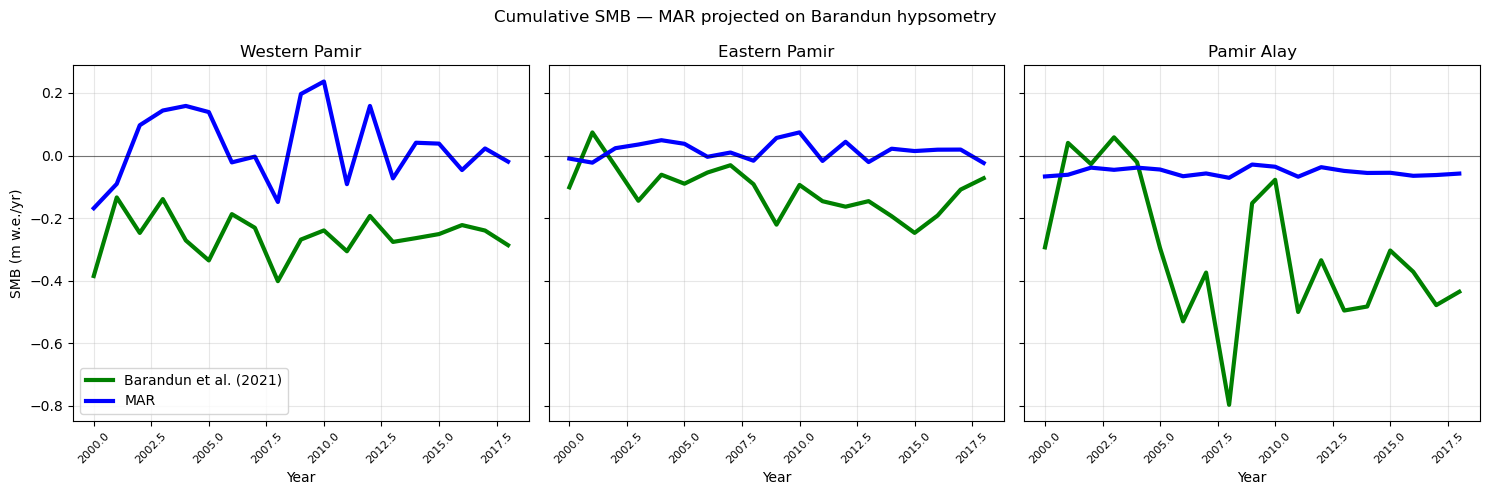

In [67]:
df_remotes_sensing = [baran_df_WP, baran_df_EP, baran_df_PA]
df_mar = [smb_mar_WP_baran, smb_mar_EP_baran, smb_mar_PA_baran]
titles = ['Western Pamir', 'Eastern Pamir', 'Pamir Alay']

yr_start = pd.to_datetime(yr_start_baran).year
yr_stop =  pd.to_datetime(yr_stop_baran).year

# Années pour sélectionner les colonnes de df_dus
yrs_str = [str(y) for y in range(yr_start, yr_stop + 1)]
# Années pour le graphique
yrs = np.arange(yr_start, yr_stop + 1)


fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5),
    sharex=True,
    sharey=True
)


for ax, title, df, smb_mar in zip(
    axes, titles, df_remotes_sensing, df_mar
):

    # ========================================================
    # Remote Sensing dataset
    # ========================================================
    cum_smb = df[yrs_str]#.cumsum(axis=1)
    weighted_mean_cum = (
        cum_smb.mul(df["area"], axis=0).sum(axis=0)
        / df["area"].sum()
    )

    ax.plot(
        yrs,
        weighted_mean_cum,
        lw=3,
        label="Barandun et al. (2021)",
        color = 'green'
    )

    # ========================================================
    # MAR
    # ========================================================
    smb_mar_sel = smb_mar.sel(
        time=smb_mar.time.dt.year.isin(
            range(yr_start, yr_stop + 1)
        )
    )
    smb_mar_cum = smb_mar_sel#.cumsum(dim="time")
    
    ax.plot(
        smb_mar_cum.time.dt.year.values,
        smb_mar_cum,
        lw=3,
        label="MAR",
        color = 'blue'
    )
    
    # ========================================================
    # MISE EN FORME du PLOT
    # ======================================================== 
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.grid(
        alpha=0.3
    )
    
    ax.axhline(
        0,
        color="black",
        lw=0.8,
        alpha=0.5
    )
    
    ax.tick_params(
        axis="x",
        labelsize=8,
        labelrotation=45
    )

axes[0].set_ylabel(
    "SMB (m w.e./yr)"
)

axes[0].legend()

plt.suptitle(
    "Cumulative SMB — MAR projected on Barandun hypsometry"
)

plt.tight_layout()
plt.show()

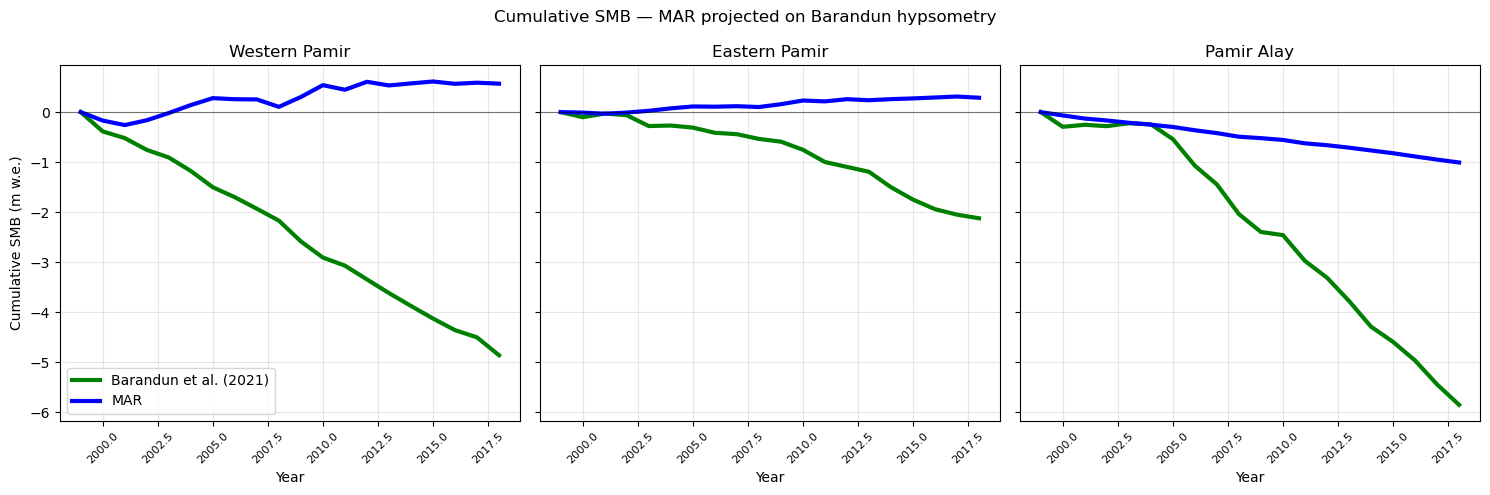

In [68]:
df_remotes_sensing = [baran_df_WP, baran_df_EP, baran_df_PA]
df_mar = [smb_mar_WP_baran, smb_mar_EP_baran, smb_mar_PA_baran]
titles = ['Western Pamir', 'Eastern Pamir', 'Pamir Alay']

yr_start = pd.to_datetime(yr_start_baran).year
yr_stop =  pd.to_datetime(yr_stop_baran).year

# Années pour sélectionner les colonnes de df_dus
yrs_str = [str(y) for y in range(yr_start, yr_stop + 1)]
# Années pour le graphique
yrs = np.arange(yr_start, yr_stop + 1)


fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5),
    sharex=True,
    sharey=True
)


for ax, title, df, smb_mar in zip(
    axes, titles, df_remotes_sensing, df_mar
):

    # ========================================================
    # Remote Sensing dataset
    # ========================================================
    cum_smb = df[yrs_str].cumsum(axis=1)
    weighted_mean_cum = (
        cum_smb.mul(df["area"], axis=0).sum(axis=0)
        / df["area"].sum()
    )
    # Ajouter un point initial à zéro
    yrs_plot = np.insert(yrs, 0, yr_start - 1)
    weighted_mean_cum_plot = np.insert(
        weighted_mean_cum.values,
        0,
        0
    )

    ax.plot(
        yrs_plot,
        weighted_mean_cum_plot,
        lw=3,
        label="Barandun et al. (2021)",
        color = 'green'
    )

    # ========================================================
    # MAR
    # ========================================================
    smb_mar_sel = smb_mar.sel(
        time=smb_mar.time.dt.year.isin(
            range(yr_start, yr_stop + 1)
        )
    )
    smb_mar_cum = smb_mar_sel.cumsum(dim="time")
    
    # Ajouter un point initial à zéro
    mar_years_plot = np.insert(
        smb_mar_cum.time.dt.year.values,
        0,
        yr_start - 1
    )
    smb_mar_cum_plot = np.insert(
        smb_mar_cum.values,
        0,
        0
    )

    ax.plot(
        mar_years_plot,
        smb_mar_cum_plot,
        lw=3,
        label="MAR",
        color = 'blue'
    )
    
    # ========================================================
    # PLOT
    # ======================================================== 
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.grid(
        alpha=0.3
    )
    
    ax.axhline(
        0,
        color="black",
        lw=0.8,
        alpha=0.5
    )
    
    ax.tick_params(
        axis="x",
        labelsize=8,
        labelrotation=45
    )

axes[0].set_ylabel(
    "Cumulative SMB (m w.e.)"
)

axes[0].legend()

plt.suptitle(
    "Cumulative SMB — MAR projected on Barandun hypsometry"
)

plt.tight_layout()
plt.show()

In [82]:
# Calcul SMB par décénnie MAR et Barandun + biais

df_remotes_sensing = [baran_df_WP, baran_df_EP, baran_df_PA]
df_mar = [smb_mar_WP_baran, smb_mar_EP_baran, smb_mar_PA_baran]

titles = ["Western Pamir", "Eastern Pamir", "Pamir Alay"]

yr_start = pd.to_datetime(yr_start_baran).year
yr_stop = pd.to_datetime(yr_stop_baran).year

yrs = np.arange(yr_start, yr_stop + 1)
yrs_str = [str(y) for y in yrs]

decadal_results = []

for title, df, smb_mar in zip(titles, df_remotes_sensing, df_mar):

    # Remote sensing
    smb_rs = (
        df[yrs_str]
        .mul(df["area"], axis=0)
        .sum(axis=0)
        / df["area"].sum()
    )

    smb_rs.index = yrs

    # MAR 
    smb_mar = smb_mar.sel(
        time=smb_mar.time.dt.year.isin(yrs)
    )

    smb_mar_series = pd.Series(
        smb_mar.values,
        index=smb_mar.time.dt.year.values
    )

    # Décennies
    decades = (yrs // 10) * 10

    for decade in np.unique(decades):

        mask = decades == decade

        sum_rs = smb_rs.iloc[mask].sum()
        sum_mar = smb_mar_series.iloc[mask].sum()

        decadal_results.append({
            "Massif": title,
            "Decade": f"{decade}s",
            "SMB_rs": sum_rs,
            "SMB_MAR": sum_mar,
            "Difference_MAR_minus_rs": sum_mar - sum_rs,
            "N_years": mask.sum()
        })

df_decadal_baran = pd.DataFrame(decadal_results)

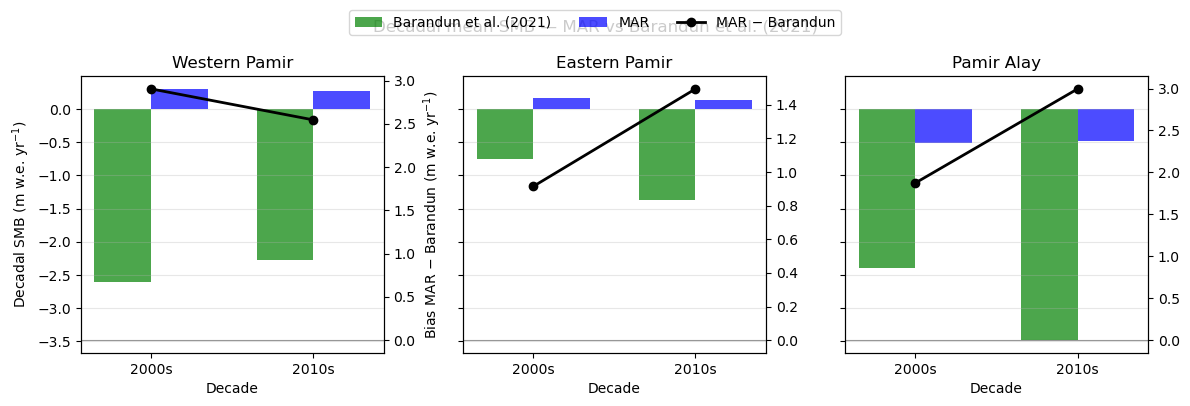

In [83]:
# Plot SMB par décennie MAR et Barandun + biais

fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 4),
    sharey=True
)

# Stocker les axes secondaires
ax_diffs = []

for ax, title in zip(axes, titles):

    data = df_decadal_baran[
        df_decadal_baran["Massif"] == title
    ].copy()

    x = np.arange(len(data))
    width = 0.35

    # ========================================================
    # SMB Remote Sensing / Barandun
    # ========================================================
    ax.bar(
        x - width / 2,
        data["SMB_rs"],
        width=width,
        color="green",
        alpha=0.7,
        label="Barandun et al. (2021)"
    )

    # ========================================================
    # SMB MAR
    # ========================================================
    ax.bar(
        x + width / 2,
        data["SMB_MAR"],
        width=width,
        color="blue",
        alpha=0.7,
        label="MAR"
    )

    # ========================================================
    # Axe secondaire pour le biais
    # ========================================================
    ax_diff = ax.twinx()

    # Stocker l'axe secondaire
    ax_diffs.append(ax_diff)

    ax_diff.plot(
        x,
        data["Difference_MAR_minus_rs"],
        color="black",
        marker="o",
        linewidth=2,
        label="MAR − Barandun"
    )

    # Ligne zéro
    ax_diff.axhline(
        0,
        color="black",
        linewidth=0.8,
        alpha=0.4
    )

    # ========================================================
    # Mise en forme
    # ========================================================
    ax.set_title(title)

    ax.set_xticks(x)
    ax.set_xticklabels(
        data["Decade"]
    )

    ax.set_xlabel("Decade")

    ax.grid(
        axis="y",
        alpha=0.3
    )


# ============================================================
# Axe Y principal
# ============================================================

axes[0].set_ylabel(
    "Decadal SMB (m w.e. yr$^{-1}$)"
)


# ============================================================
# Axe Y secondaire
# ============================================================

ax_diffs[0].set_ylabel(
    "Bias MAR − Barandun (m w.e. yr$^{-1}$)"
)


# ============================================================
# Légende commune
# ============================================================

handles1, labels1 = axes[0].get_legend_handles_labels()

handles2, labels2 = ax_diffs[0].get_legend_handles_labels()

fig.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.02)
)


# ============================================================
# Titre
# ============================================================

plt.suptitle(
    "Decadal mean SMB — MAR vs Barandun et al. (2021)"
)

plt.tight_layout()

plt.show()

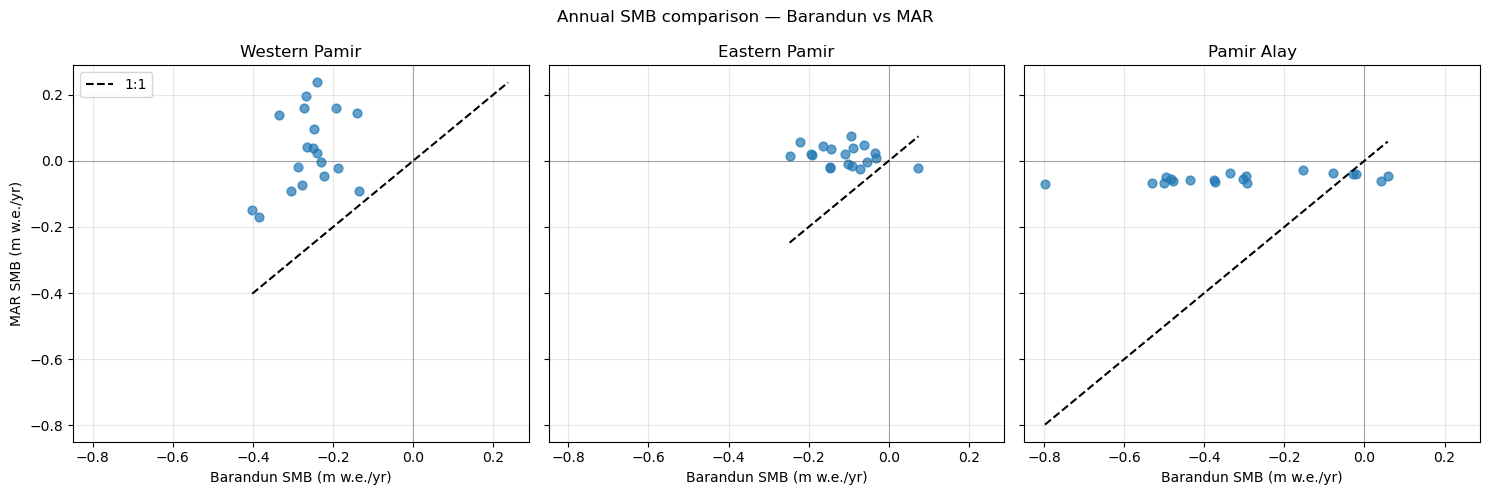

In [81]:
df_remotes_sensing = [baran_df_WP, baran_df_EP, baran_df_PA]
df_mar = [smb_mar_WP_baran, smb_mar_EP_baran, smb_mar_PA_baran]

titles = [
    "Western Pamir",
    "Eastern Pamir",
    "Pamir Alay"
]

yr_start = pd.to_datetime(yr_start_baran).year
yr_stop = pd.to_datetime(yr_stop_baran).year

# Années
yrs_str = [str(y) for y in range(yr_start, yr_stop + 1)]


fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5),
    sharex=True,
    sharey=True
)


for ax, title, df, smb_mar in zip(
    axes, titles, df_remotes_sensing, df_mar
):

    # ========================================================
    # Barandun et al. (2021)
    # ========================================================

    smb_baran = (
        df[yrs_str]
        .mul(df["area"], axis=0)
        .sum(axis=0)
        / df["area"].sum()
    )

    # ========================================================
    # MAR
    # ========================================================

    smb_mar_sel = smb_mar.sel(
        time=smb_mar.time.dt.year.isin(
            range(yr_start, yr_stop + 1)
        )
    )

    # ========================================================
    # Scatter plot
    # ========================================================

    ax.scatter(
        smb_baran,
        smb_mar_sel,
        s=40,
        alpha=0.7,
    )

    # ========================================================
    # Ligne 1:1
    # ========================================================

    xmin = min(smb_baran.min(), smb_mar_sel.min())
    xmax = max(smb_baran.max(), smb_mar_sel.max())

    ax.plot(
        [xmin, xmax],
        [xmin, xmax],
        color="black",
        linestyle="--",
        lw=1.5,
        label="1:1"
    )

    # ========================================================
    # Mise en forme
    # ========================================================

    ax.set_title(title)
    ax.set_xlabel("Barandun SMB (m w.e./yr)")
    ax.grid(alpha=0.3)

    ax.axhline(
        0,
        color="black",
        lw=0.8,
        alpha=0.3
    )

    ax.axvline(
        0,
        color="black",
        lw=0.8,
        alpha=0.3
    )


axes[0].set_ylabel("MAR SMB (m w.e./yr)")

axes[0].legend()

plt.suptitle(
    "Annual SMB comparison — Barandun vs MAR"
)

plt.tight_layout()
plt.show()